# resumo geral

## 1. correção dos status das entregas
com base na reunião de 21/05/2026, os status foram revisados para que a classificação de atraso representasse melhor o comportamento real das entregas:

- **EM TRÂNSITO** → status alterado para ENTREGUE, pois a existência da data de entrega confirma que a entrega foi concluída
- **PERDIDO** → na coluna `status` foi mantido como PERDIDO, mas classificado diretamente como `True`(atrasado) na coluna `entregas_atrasadas`, sem passar pela função `classificar_por_rota`, pois o pedido não foi efetivamente recebido pelo cliente — independentemente do comportamento da rota
- **DEVOLVIDO** → na coluna `status` mantido como DEVOLVIDO e classificação definida pelo comportamento histórico da rota via função `classificar_por_rota` — o resultado é aplicado diretamente na coluna `entregas_atrasadas` como `True` (atrasado) ou `False` (no prazo)

## 2. exclusão da variável `diferenca_dias`
a variável `diferenca_dias` foi utilizada como apoio para validação da lógica de classificação de atraso — calculava a diferença em dias entre `dias_transito_real` e `dias_transito_original`, indicando quantos dias a entrega demorou além da estimativa da empresa.


com a criação da nova lógica baseada no comportamento de rota (`p90_dias`, `p10_km_por_dia` e `entregas_atrasadas`), a variável tornou-se redundante. foi utilizada apenas de forma temporária para validação e demonstração — o critério definitivo para classificar uma entrega como atrasada ou no prazo é o comportamento histórico da rota.

- `entregas_atrasadas` já responde a mesma pergunta de forma mais precisa
- `diferenca_dias` depende de `dias_transito_original` que pode conter inconsistências no sistema
- a nova lógica considera o comportamento histórico de cada rota — mais robusto que a estimativa original da empresa
- menos colunas = dataset mais limpo para o Power BI

## 3. nova lógica de classificação de atraso (solicitação da Tati)
a classificação de atraso foi atualizada com base no comportamento histórico de cada rota, substituindo a classificação anterior baseada apenas no status original.

**novas colunas criadas:**
- `p90_dias` → percentil 90 dos dias de trânsito real por rota
- `p10_km_por_dia` → percentil 10 do km_por_dia por rota
- `entregas_atrasadas` → booleana (`True` / `False`) — baseada no comportamento da rota

**critérios utilizados:**
- **percentil 90 dos dias de trânsito real** → limite máximo de dias aceitável por rota
- **percentil 10 do km_por_dia** → limite mínimo de velocidade operacional por rota

uma entrega é classificada como `True` se qualquer um dos dois critérios for verdadeiro.

**validação:**
- 246 entregas abaixo do P10 de km/dia
- 218 entregas acima do P90 de dias de trânsito
- 92 entregas atendem aos dois critérios simultaneamente
- 10 entregas PERDIDO já classificadas pelo comportamento da rota
- 35 entregas PERDIDO classificadas diretamente como `True`
- **246 + 218 - 92 - 10 + 45 = 407**

## 4. remoção de análises de outliers
- **análise de outliers** → removida por ser redundante com as estatísticas descritivas e com a classificação por comportamento de rota (P90 e P10)

## 5. análises feitas e mantidas
as análises de taxa de atraso com base na coluna `entregas_atrasadas`:

- **por transportadora** → Amazon Logistics lidera com 24.72%, USPS é a mais confiável com 16.78%
- **por rota** → Warehouse_ATL → Detroit, Warehouse_HOU → Portland e Warehouse_SF → Chicago lideram com 41.67%
- **por destino** → New York lidera com 23.93%, Phoenix é o destino mais confiável com 16.44%
- **por transportadora e rota** → Amazon Logistics | Warehouse_BOS → Portland lidera com 50%, com filtro mínimo de 5 envios por combinação
- **evolução por mês de envio e entrega** → comparativo entre as duas taxas revelou efeito cascata — picos de atraso no envio impactam as entregas do mês seguinte.

# sugestão sobre nulos no dataset
**nulos em `data_entrega` (31 registros) → excluir**

sem `data_entrega` não é possível calcular `dias_transito_real` e consequentemente `km_por_dia`, impossibilitando a classificação pelo comportamento da rota. esses registros ficam com `NaN` em `entregas_atrasadas` e não contribuem para nenhuma análise.

representam apenas 1.5% do dataset — a exclusão não impactará os resultados.

**nulos em `custo` (39 registros) → manter**

o `custo` não é utilizado na classificação de atraso — esses registros foram classificados normalmente pela função `classificar_por_rota` e contribuem para todas as análises de rota, transportadora e destino.

as análises que envolvem a coluna `custo` excluem os nulos automaticamente via pandas, a exclusão desses registros representaria perda de informação válida sem nenhum benefício.

**pendente:** alinhamento com o time para confirmar a exclusão.

# ══════════════════════════════════
# PARTE 1 — IMPORTAÇÃO, EXPLORAÇÃO E TRATAMENTO DOS DADOS
# ══════════════════════════════════

# importação

In [1]:
# INSTALAR BIBLIOTECAS
!pip install sqlalchemy psycopg2-binary python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 27.8 MB/s eta 0:00:00


In [2]:
# IMPORTAR BIBLIOTECAS
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from urllib.parse import quote_plus  # necessário para tratar caracteres especiais na senha
from google.colab import drive       # necessário para acessar o .env salvo no Google Drive
import os

# CARREGAR O .env
# O .env foi salvo no Google Drive para garantir persistência entre sessões
# No Colab, o .env some quando a sessão reinicia — por isso usamos o Drive
drive.mount('/content/drive')
load_dotenv('/content/drive/MyDrive/.env', override=True)

# GUARDAR AS VARIÁVEIS
user     = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host     = os.getenv("DB_HOST")
port     = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

# Verificação: garante que o .env foi lido corretamente antes de prosseguir
print(password is None)  # False = variáveis carregadas com sucesso

Mounted at /content/drive
False


In [3]:
# 5. STRING DE CONEXÃO
# quote_plus converte caracteres especiais (como # e !) para formato aceito na URL
password_encoded = quote_plus(password)
connection_string = f"postgresql://{user}:{password_encoded}@{host}:{port}/{database}?sslmode=require"

# 6. CRIAR ENGINE
engine = create_engine(connection_string)

# 7. CONSULTA SQL
query = "SELECT * FROM silver.entregas_clean"

# 8. LER NO DATAFRAME
df = pd.read_sql(query, engine)

# 9. FECHAR CONEXÃO
# Importante: evita conexões abertas desnecessárias e problemas de limite no Neon
engine.dispose()

df.head()

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real
0,SH10000,Warehouse_MIA,San Francisco,UPS,DELIVERED,2023-10-02,2023-10-04,25.7,67.46,291.0,468.32,2,2.0
1,SH10001,Warehouse_MIA,Atlanta,DHL,DELIVERED,2023-12-06,2023-12-09,38.9,268.85,1225.0,1971.44,3,3.0
2,SH10002,Warehouse_LA,Houston,DHL,DELIVERED,2023-09-18,2023-09-20,37.2,74.35,220.0,354.05,2,2.0
3,SH10003,Warehouse_BOS,Seattle,ONTRAC,DELIVERED,2023-01-26,2023-02-04,42.6,187.04,1156.0,1860.40,9,9.0
4,SH10004,Warehouse_SF,Dallas,ONTRAC,DELIVERED,2023-06-03,2023-06-06,7.9,120.01,1017.0,1636.70,3,3.0


In [4]:
# IMPORTAR MAIS BIBLIOTECAS PARA MENSURAÇÃO E ANÁLISE DOS DADOS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import chi2_contingency

In [5]:
display(df)

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real
0,SH10000,Warehouse_MIA,San Francisco,UPS,DELIVERED,2023-10-02,2023-10-04,25.7,67.46,291.0,468.32,2,2.0
1,SH10001,Warehouse_MIA,Atlanta,DHL,DELIVERED,2023-12-06,2023-12-09,38.9,268.85,1225.0,1971.44,3,3.0
2,SH10002,Warehouse_LA,Houston,DHL,DELIVERED,2023-09-18,2023-09-20,37.2,74.35,220.0,354.05,2,2.0
3,SH10003,Warehouse_BOS,Seattle,ONTRAC,DELIVERED,2023-01-26,2023-02-04,42.6,187.04,1156.0,1860.40,9,9.0
4,SH10004,Warehouse_SF,Dallas,ONTRAC,DELIVERED,2023-06-03,2023-06-06,7.9,120.01,1017.0,1636.70,3,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1978,SH11995,Warehouse_BOS,San Francisco,FEDEX,DELIVERED,2023-01-18,2023-01-23,7.9,217.78,1616.0,2600.69,5,5.0
1979,SH11996,Warehouse_HOU,Phoenix,UPS,DELIVERED,2023-10-27,2023-11-01,36.5,279.47,1708.0,2748.75,5,5.0
1980,SH11997,Warehouse_HOU,Portland,LASERSHIP,DELIVERED,2023-02-13,2023-02-19,11.4,250.32,1912.0,3077.06,6,6.0
1981,SH11998,Warehouse_SEA,Detroit,USPS,DELIVERED,2023-10-17,2023-10-22,10.9,272.31,2188.0,3521.24,5,5.0


# quantidade de linhas e colunas

In [6]:
df.shape

(1983, 13)

# colunas

In [7]:
print(df.columns)

Index(['id_envio', 'armazem_origem', 'destino', 'transportadora', 'status',
       'data_envio', 'data_entrega', 'peso_kg', 'custo', 'distancia_milhas',
       'distancia_km', 'dias_transito_original', 'dias_transito_real'],
      dtype='object')


# tipo de cada coluna

In [8]:
print(df.dtypes)

id_envio                   object
armazem_origem             object
destino                    object
transportadora             object
status                     object
data_envio                 object
data_entrega               object
peso_kg                   float64
custo                     float64
distancia_milhas          float64
distancia_km              float64
dias_transito_original      int64
dias_transito_real        float64
dtype: object


# nulos em cada coluna

In [9]:
df.isnull().sum()

,0
id_envio,0
armazem_origem,0
destino,0
transportadora,0
status,0
data_envio,0
data_entrega,31
peso_kg,0
custo,39
distancia_milhas,0


In [10]:
print(df[df.isnull().any(axis=1)].shape[0])

70


In [11]:
null_percentage = df[['custo', 'data_entrega', 'dias_transito_real']].isnull().mean() * 100

print("Percentage of null values:")
print(null_percentage)

Percentage of null values:
custo                 1.966717
data_entrega          1.563288
dias_transito_real    1.563288
dtype: float64


# verificação de duplicidade em id_envio

In [12]:
df['id_envio'].duplicated().sum()

np.int64(0)

# colunas peso_kg, custo e distancia_milhas

In [13]:
colunas = ["peso_kg", "custo", "distancia_milhas"]

for col in colunas:
    abaixo = (df[col] < 0).sum()
    igual_zero = (df[col] == 0).sum()
    acima = (df[col] > 0).sum()

    print(f"\n── {col} ──")
    print(f"  Abaixo de zero : {abaixo}")
    print(f"  Igual a zero   : {igual_zero}")
    print(f"  Acima de zero  : {acima}")


── peso_kg ──
  Abaixo de zero : 0
  Igual a zero   : 1
  Acima de zero  : 1982

── custo ──
  Abaixo de zero : 0
  Igual a zero   : 0
  Acima de zero  : 1944

── distancia_milhas ──
  Abaixo de zero : 0
  Igual a zero   : 0
  Acima de zero  : 1983


# quantidade de transportadora

In [14]:
df['transportadora'].nunique()

7

In [15]:
df['transportadora'].value_counts()

,count
transportadora,
LASERSHIP,302
ONTRAC,297
FEDEX,291
USPS,286
DHL,280
AMAZON LOGISTICS,271
UPS,256


# quantidade de armazens

In [16]:
df['armazem_origem'].nunique()

10

In [17]:
df['armazem_origem'].value_counts()

,count
armazem_origem,
Warehouse_LA,218
Warehouse_SF,214
Warehouse_HOU,211
Warehouse_ATL,203
Warehouse_MIA,199
Warehouse_CHI,195
Warehouse_DEN,195
Warehouse_BOS,192
Warehouse_SEA,189


# dias previstos em dias_transito_original

In [18]:
df['dias_transito_original'].unique()

array([ 2,  3,  9,  4,  7,  5,  6,  1,  8, 11, 10, 12])

# dias previstos em dias_transito_real

In [19]:
df['dias_transito_real'].unique()

array([ 2.,  3.,  9.,  4.,  7.,  5.,  6.,  1., nan, 16., 18.,  8., 10.,
       11., 13., 14., 15., 12., 17., 20., 19.])

# destinos mencionados

In [20]:
df['destino'].value_counts()

,count
destino,
Chicago,154
Minneapolis,147
Phoenix,146
Portland,145
Denver,140
Detroit,139
Dallas,136
Atlanta,133
San Francisco,128


In [21]:
df['destino'].unique()

array(['San Francisco', 'Atlanta', 'Houston', 'Seattle', 'Dallas',
       'New York', 'Portland', 'Detroit', 'Chicago', 'Boston', 'Phoenix',
       'Miami', 'Minneapolis', 'Los Angeles', 'Denver'], dtype=object)

In [22]:
df['destino'].nunique()

15

# conversão de datas de envio e entrega

In [23]:
df['data_envio'] = pd.to_datetime(df['data_envio'], errors='coerce')

In [24]:
df['data_entrega'] = pd.to_datetime(df['data_entrega'], errors='coerce')

# anos existentes nas datas

In [25]:
sorted(df['data_envio'].dt.year.unique())

[np.int32(2023)]

In [26]:
sorted(df['data_entrega'].dt.year.unique())

[np.float64(2023.0), np.float64(2024.0), np.float64(nan)]

# após a conversão de datas, não constam registros de nulos

In [27]:
df.isnull().sum()

,0
id_envio,0
armazem_origem,0
destino,0
transportadora,0
status,0
data_envio,0
data_entrega,31
peso_kg,0
custo,39
distancia_milhas,0


# conversão de datas realizadas

In [28]:
print(df.dtypes)

id_envio                          object
armazem_origem                    object
destino                           object
transportadora                    object
status                            object
data_envio                datetime64[ns]
data_entrega              datetime64[ns]
peso_kg                          float64
custo                            float64
distancia_milhas                 float64
distancia_km                     float64
dias_transito_original             int64
dias_transito_real               float64
dtype: object


# datas de envio - inicio e fim

In [29]:
df['data_envio'].min(), df['data_envio'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2023-12-31 00:00:00'))

# datas de entrega - inicio e fim

In [30]:
df['data_entrega'].min(), df['data_entrega'].max()

(Timestamp('2023-01-03 00:00:00'), Timestamp('2024-01-12 00:00:00'))

# verificação de datas invalidas

In [31]:
n_invalidas = df['data_envio'].isna().sum()
print("Quantidade de datas inválidas:", n_invalidas)

Quantidade de datas inválidas: 0


In [32]:
n_invalidas = df['data_entrega'].isna().sum()
print("Quantidade de datas inválidas:", n_invalidas)

Quantidade de datas inválidas: 31


# status e quantidade em cada um

In [33]:
df['status'].value_counts()

,count
status,
DELIVERED,1636
DELAYED,196
IN TRANSIT,75
LOST,45
RETURNED,31


# tradução das opções em `status`

In [34]:
df['status'] = df['status'].replace({
    'DELIVERED': 'ENTREGUE',
    'DELAYED': 'ATRASADO',
    'LOST': 'PERDIDO',
    'RETURNED': 'DEVOLVIDO',
    'IN TRANSIT': 'EM TRÂNSITO'
})

In [35]:
print(df['status'].value_counts())

status
ENTREGUE       1636
ATRASADO        196
EM TRÂNSITO      75
PERDIDO          45
DEVOLVIDO        31
Name: count, dtype: int64


# cálculo de `diferenca_dias` (não é variável)

calcula a diferença em dias entre o trânsito real e o original.

- valores **positivos** → a entrega demorou mais dias do que o previsto em `dias_transito_original`
- valor **zero** → a entrega foi concluída dentro do prazo previsto

**observação:** `diferenca_dias` não reflete necessariamente se a entrega chegou na data correta ao cliente — apenas indica se o tempo real de trânsito foi maior, igual ou menor que o tempo originalmente estimado.


In [36]:
diferenca_dias = df['dias_transito_real'] - df['dias_transito_original']

In [37]:
print(diferenca_dias.value_counts().sort_index())

0.0     1759
1.0       19
2.0        9
3.0        7
4.0       18
5.0       15
6.0       15
7.0       15
8.0       15
9.0       13
10.0      23
11.0      18
12.0      10
13.0      16
Name: count, dtype: int64


# quantidade de dias previstos em diferenca_dias

In [38]:
diferenca_dias.unique()

array([ 0.,  1., nan,  5., 13., 10.,  6.,  3.,  7., 12.,  4.,  9., 11.,
        8.,  2.])

# nulos em diferenca_dias

In [39]:
display(diferenca_dias.isnull().sum())

np.int64(31)

# quantidade de diferenca_dias > 0

In [40]:
(diferenca_dias > 0).sum()

np.int64(193)

# observação sobre status ENTREGUE, ATRASADO, EM TRÂNSITO, PERDIDO e DEVOLVIDO

**ENTREGUE (1636 envios):**
- 1610 com `diferenca_dias = 0` → entregues no prazo
- 26 com `diferenca_dias = NaN` → sem informação de trânsito original

**ATRASADO (196 envios):**
- diferença varia de 1 a 13 dias
- 5 registros com `diferenca_dias = NaN` → sem informação de trânsito original

**EM TRÂNSITO (75 envios):**
- `diferenca_dias = 0` para todos → ainda dentro do prazo no momento da extração
- não foram classificados como atrasados pois não há informação suficiente para confirmar atraso efetivo

**PERDIDO (45 envios):**
- maioria com `diferenca_dias = 0`, com outliers de 13 e 3 dias
- trânsito real chegou a 16 dias antes de ser classificado como perdido

**DEVOLVIDO (31 envios):**
- `diferenca_dias = 0` para todos os registros
- devolvidos dentro do prazo previsto
- motivo da devolução não identificado no dataset



In [41]:
# quantidade de diferenca_dias em cada uma delas
for status in df['status'].unique():
    print(f'\n=== STATUS: {status} ===')
    subset = diferenca_dias[df['status'] == status]
    print(f'Total: {len(subset)}')
    print(subset.value_counts(dropna=False))


=== STATUS: ENTREGUE ===
Total: 1636
0.0    1610
NaN      26
Name: count, dtype: int64

=== STATUS: ATRASADO ===
Total: 196
10.0    23
1.0     19
11.0    18
4.0     18
5.0     15
13.0    15
8.0     15
6.0     15
7.0     15
9.0     13
12.0    10
2.0      9
3.0      6
NaN      5
Name: count, dtype: int64

=== STATUS: PERDIDO ===
Total: 45
0.0     43
13.0     1
3.0      1
Name: count, dtype: int64

=== STATUS: EM TRÂNSITO ===
Total: 75
0.0    75
Name: count, dtype: int64

=== STATUS: DEVOLVIDO ===
Total: 31
0.0    31
Name: count, dtype: int64


# ══════════════════════════════════
# PARTE 2 — ANÁLISE E TRANSFORMAÇÃO DA COLUNA `STATUS` E CRIAÇÃO DE VARIÁVEIS
# ══════════════════════════════════

In [42]:
df['status'].value_counts()

,count
status,
ENTREGUE,1636
ATRASADO,196
EM TRÂNSITO,75
PERDIDO,45
DEVOLVIDO,31


# correção do status EM TRÂNSITO → ENTREGUE

In [43]:
df['status'] = df['status'].replace('EM TRÂNSITO', 'ENTREGUE')

In [44]:
df['status'].value_counts()

,count
status,
ENTREGUE,1711
ATRASADO,196
PERDIDO,45
DEVOLVIDO,31


 # conferir se os valores são consistentes entre si (1 milha ≈ 1.609 km)

In [45]:
# Validação: distancia_milhas × 1.609 deve ser próximo de distancia_km
diferenca = (df['distancia_km'] - df['distancia_milhas'] * 1.60934).abs()

print(f"Diferença máxima: {diferenca.max():.2f} km")
print(f"Diferença média:  {diferenca.mean():.2f} km")
print(f"Registros com diferença > 1 km: {(diferenca > 1).sum()}")

Diferença máxima: 0.01 km
Diferença média:  0.00 km
Registros com diferença > 1 km: 0


# quantidade de envios por rota

In [46]:
print(df.groupby(['armazem_origem', 'destino']).size().to_string())

armazem_origem  destino      
Warehouse_ATL   Atlanta          13
                Boston           17
                Chicago          15
                Dallas           16
                Denver           13
                Detroit          12
                Houston          16
                Los Angeles       9
                Miami            13
                Minneapolis      19
                New York          6
                Phoenix          17
                Portland         10
                San Francisco    17
                Seattle          10
Warehouse_BOS   Atlanta          11
                Boston           10
                Chicago          19
                Dallas           13
                Denver           13
                Detroit          12
                Houston          13
                Los Angeles      16
                Miami            12
                Minneapolis      12
                New York         10
                Phoenix          1

# calculo do percentil 90 dos dias de trânsito real por rotas

In [47]:
# percentil 90 dos dias de trânsito real por rota
print(df.groupby(['armazem_origem', 'destino'])['dias_transito_real'].quantile(0.90).to_string())

armazem_origem  destino      
Warehouse_ATL   Atlanta           7.6
                Boston           12.4
                Chicago           9.0
                Dallas           11.0
                Denver            6.8
                Detroit           6.9
                Houston           6.0
                Los Angeles      12.0
                Miami            12.8
                Minneapolis      11.6
                New York          4.5
                Phoenix           9.0
                Portland          7.7
                San Francisco     8.2
                Seattle           5.1
Warehouse_BOS   Atlanta           6.0
                Boston            9.2
                Chicago           5.2
                Dallas            5.8
                Denver            8.8
                Detroit           7.8
                Houston           6.8
                Los Angeles       6.5
                Miami             7.9
                Minneapolis       9.6
                New 

In [48]:
acima_p90 = df['dias_transito_real'] > df.groupby(['armazem_origem', 'destino'])['dias_transito_real'].transform(lambda x: np.percentile(x.dropna(), 90))

print(f'Total acima do P90 dias: {acima_p90.sum()}')

Total acima do P90 dias: 218


# criação da variável `p90_dias`

In [49]:
df['p90_dias'] = df.groupby(['armazem_origem', 'destino'])['dias_transito_real'].transform(lambda x: np.percentile(x.dropna(), 90))

In [50]:
df.columns

Index(['id_envio', 'armazem_origem', 'destino', 'transportadora', 'status',
       'data_envio', 'data_entrega', 'peso_kg', 'custo', 'distancia_milhas',
       'distancia_km', 'dias_transito_original', 'dias_transito_real',
       'p90_dias'],
      dtype='object')

# criação da variável `km_por_dia`

In [51]:
# relação entre distância percorrida e dias reais de trânsito
# NaN quando dias_transito_real é nulo
df['km_por_dia'] = df['distancia_km'] / df['dias_transito_real']

In [52]:
df['km_por_dia'].head(10)

,km_por_dia
0,234.160000
1,657.146667
2,177.025000
3,206.711111
4,545.566667
5,481.730000
6,612.355000
7,359.955556
8,476.364286
9,172.200000


In [53]:
df.columns

Index(['id_envio', 'armazem_origem', 'destino', 'transportadora', 'status',
       'data_envio', 'data_entrega', 'peso_kg', 'custo', 'distancia_milhas',
       'distancia_km', 'dias_transito_original', 'dias_transito_real',
       'p90_dias', 'km_por_dia'],
      dtype='object')

# percentil 10 do km_por_dia por rota

In [54]:
print(df.groupby(['armazem_origem', 'destino'])['km_por_dia'].quantile(0.10).to_string())

armazem_origem  destino      
Warehouse_ATL   Atlanta          308.241333
                Boston           177.353969
                Chicago          201.488900
                Dallas           241.221111
                Denver           195.536000
                Detroit          318.327000
                Houston          314.827917
                Los Angeles       62.297600
                Miami            189.442257
                Minneapolis      173.232130
                New York         420.306667
                Phoenix          197.948250
                Portland         172.130310
                San Francisco     66.980667
                Seattle          157.149000
Warehouse_BOS   Atlanta          196.340000
                Boston           315.343091
                Chicago          296.332133
                Dallas           252.985500
                Denver           293.832667
                Detroit          178.072035
                Houston          346.060667
  

In [55]:
abaixo_p10 = df['km_por_dia'] < df.groupby(['armazem_origem', 'destino'])['km_por_dia'].transform(lambda x: np.percentile(x.dropna(), 10))

print(f'Total abaixo do P10 km/dia: {abaixo_p10.sum()}')

Total abaixo do P10 km/dia: 246


# criação da variável `p10_km_por_dia`

In [56]:
df['p10_km_por_dia'] = df.groupby(['armazem_origem', 'destino'])['km_por_dia'].transform(lambda x: np.percentile(x.dropna(), 10))

In [57]:
df.columns

Index(['id_envio', 'armazem_origem', 'destino', 'transportadora', 'status',
       'data_envio', 'data_entrega', 'peso_kg', 'custo', 'distancia_milhas',
       'distancia_km', 'dias_transito_original', 'dias_transito_real',
       'p90_dias', 'km_por_dia', 'p10_km_por_dia'],
      dtype='object')

# função de classificação por comportamento de rota
- usada para: ENTREGUE, DEVOLVIDO (e ATRASADO remanescentes)

**lógica:**
   - utiliza as colunas `p90_dias` e `p10_km_por_dia` já calculadas por rota no `df`
   - ATRASADO se: dias_transito_real > p90_dias OU km_por_dia < p10_km_por_dia
   - NO PRAZO caso contrário
  
===================================================

# como a função classificar_por_rota funciona

a função percorre cada linha do dataset e classifica cada entrega como ATRASADO ou NO PRAZO com base no comportamento histórico da rota, utilizando os percentis já calculados nas colunas `p90_dias` e `p10_km_por_dia`.

**passo a passo:**

1. para cada entrega, lê os valores de `dias_transito_real`, `km_por_dia`, `p90_dias` e `p10_km_por_dia`

2. verifica:
   - se dias_transito_real > p90_dias → entrega demorou mais que o esperado para aquela rota
   - se km_por_dia < p10_km_por_dia → entrega foi mais lenta que o esperado para aquela rota
   - se qualquer um dos dois for verdadeiro → ATRASADO
   - caso contrário → NO PRAZO

3. registros sem dados suficientes (nulos) → classificados como None

In [58]:
def classificar_por_rota(df):
    """
    Classifica cada entrega como ATRASADO ou NO PRAZO
    com base no comportamento histórico da rota.
    Retorna uma Series com os valores classificados.
    """

    classificacao = pd.Series(index=df.index, dtype='object')

    for idx, row in df.iterrows():
        dias   = row['dias_transito_real']
        km_dia = row['km_por_dia']
        p90    = row['p90_dias']
        p10    = row['p10_km_por_dia']

        # Sem dados suficientes para classificar
        if pd.isna(dias) or pd.isna(km_dia):
            classificacao.loc[idx] = None
            continue

        # Fora do padrão da rota → ATRASADO
        if dias > p90 or km_dia < p10:
            classificacao.loc[idx] = 'ATRASADO'
        else:
            classificacao.loc[idx] = 'NO PRAZO'

    return classificacao

In [59]:
abaixo_p10 = df['km_por_dia'] < df['p10_km_por_dia']

print(f'Total abaixo do P10 km/dia: {abaixo_p10.sum()}')

Total abaixo do P10 km/dia: 246


In [60]:
acima_p90 = df['dias_transito_real'] > df['p90_dias']

print(f'Total acima do P90 dias: {acima_p90.sum()}')

Total acima do P90 dias: 218


In [61]:
print(f'Atrasados por ambos os critérios: {(abaixo_p10 & acima_p90).sum()}')

Atrasados por ambos os critérios: 92


# classificação de atraso por comportamento de rota - variável temporária

classificação usada foi baseada em dois critérios combinados por rota:

- P90 dos dias de trânsito real — se a entrega demorou mais que 90% das entregas daquela rota
- P10 do km_por_dia — se a velocidade operacional foi menor que 10% das entregas daquela rota

se qualquer um dos dois critérios for verdadeiro → ATRASADO, caso contrário → NO PRAZO.

**observação:** `classificacao_por_rota` é uma variável temporária usada apenas para visualização e validação do resultado — não é criada como coluna no `df`.

In [62]:
classificacao_por_rota = classificar_por_rota(df)

In [63]:
print(classificacao_por_rota.value_counts(dropna=False))

NO PRAZO    1580
ATRASADO     372
None          31
Name: count, dtype: int64


# criação da coluna entregas_atrasadas

**`entregas_atrasadas`** — booleana — derivada da função `classificar_por_rota` via `.map()`:
- `True` → entrega fora do padrão da rota (ATRASADO)
- `False` → entrega dentro do padrão da rota (NO PRAZO)
- `NaN` → sem dados suficientes para classificar (ausência de `data_entrega`)

ao mapear `ATRASADO → True` e `NO PRAZO → False`, os valores `None` não encontraram correspondência no dicionário e foram convertidos automaticamente para `NaN`, garantindo que registros sem dados suficientes não sejam classificados erroneamente como `False`.

**observação:** antes da aplicação da função, a classificação era baseada no status original — onde ATRASADO era o único status considerado atrasado. com a nova lógica, todos os status passam a ser avaliados pelo comportamento histórico da rota, exceto `PERDIDO` que é classificado diretamente como `True` em `entregas_atrasadas`, pois o pedido não foi efetivamente recebido pelo cliente.

**por que DEVOLVIDO não é classificado diretamente como NO PRAZO?**

mesmo sendo uma devolução, o processo operacional pode ter ocorrido fora do padrão da rota.

**exemplos:**
- devolução realizada dentro do tempo normal da rota → **NO PRAZO** (`False`)
- devolução que demorou mais que o P90 da rota → **ATRASADO** (`True`)
- devolução com velocidade operacional abaixo do P10 do km/dia → **ATRASADO** (`True`)

por isso, o DEVOLVIDO segue a mesma lógica da função `classificar_por_rota` — o comportamento histórico da rota é quem define se houve atraso ou não, não o status em si.

diferente do PERDIDO, que é sempre `True` pois o pedido nunca foi efetivamente recebido pelo cliente.

# criação da variável `entregas_atrasadas` - coluna booleana

In [64]:
df['entregas_atrasadas'] = classificar_por_rota(df).map({'ATRASADO': True, 'NO PRAZO': False})

In [65]:
df.columns

Index(['id_envio', 'armazem_origem', 'destino', 'transportadora', 'status',
       'data_envio', 'data_entrega', 'peso_kg', 'custo', 'distancia_milhas',
       'distancia_km', 'dias_transito_original', 'dias_transito_real',
       'p90_dias', 'km_por_dia', 'p10_km_por_dia', 'entregas_atrasadas'],
      dtype='object')

# PERDIDO → classificado diretamente como True na coluna entregas_atrasadas — na coluna status PERDIDO foi mantido

In [66]:
df.loc[df['status'] == 'PERDIDO', 'entregas_atrasadas'] = True

In [67]:
df[['armazem_origem', 'destino', 'distancia_km', 'status', 'dias_transito_real', 'p90_dias', 'km_por_dia', 'p10_km_por_dia', 'entregas_atrasadas']].head(5)

,armazem_origem,destino,distancia_km,status,dias_transito_real,p90_dias,km_por_dia,p10_km_por_dia,entregas_atrasadas
0,Warehouse_MIA,San Francisco,468.32,ENTREGUE,2.0,7.0,234.160000,311.140000,True
1,Warehouse_MIA,Atlanta,1971.44,ENTREGUE,3.0,11.6,657.146667,68.133488,False
2,Warehouse_LA,Houston,354.05,ENTREGUE,2.0,11.4,177.025000,166.637389,False
3,Warehouse_BOS,Seattle,1860.40,ENTREGUE,9.0,10.2,206.711111,192.584500,False
4,Warehouse_SF,Dallas,1636.70,ENTREGUE,3.0,5.6,545.566667,267.257333,False


In [68]:
print(df['entregas_atrasadas'].value_counts(dropna=False))

entregas_atrasadas
False    1545
True      407
NaN        31
Name: count, dtype: int64


In [69]:
# agrupamento por entregas_atrasadas e status
df.groupby(['entregas_atrasadas', 'status']).size().sort_index()

entregas_atrasadas  status   
False               ATRASADO       40
                    DEVOLVIDO      28
                    ENTREGUE     1477
True                ATRASADO      151
                    DEVOLVIDO       3
                    ENTREGUE      208
                    PERDIDO        45
dtype: int64

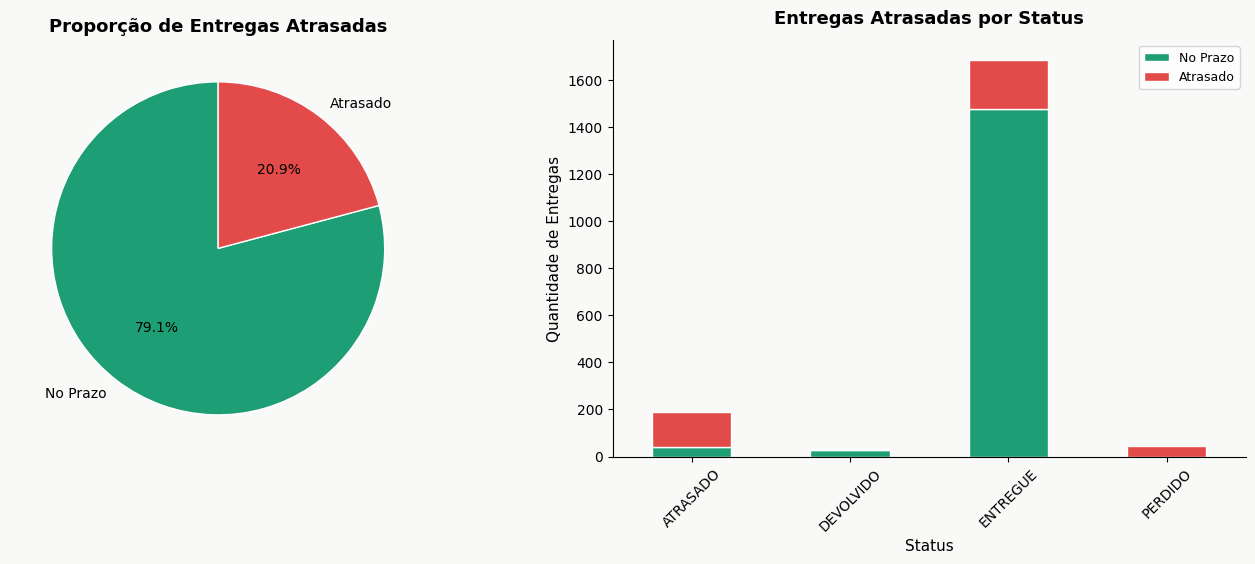

In [70]:
# pizza — proporção de entregas atrasadas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#f9f9f8')

# pizza
contagem = df['entregas_atrasadas'].value_counts(dropna=True)
labels = ['No Prazo', 'Atrasado']
cores = ['#1D9E75', '#E24B4A']

axes[0].pie(contagem, labels=labels, colors=cores, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[0].set_title('Proporção de Entregas Atrasadas', fontsize=13, fontweight='bold')
axes[0].set_facecolor('#f9f9f8')

# barras por status
dados_status = (
    df.groupby(['status', 'entregas_atrasadas'])['id_envio']
    .count()
    .unstack(fill_value=0)
    .rename(columns={True: 'Atrasado', False: 'No Prazo'})
)

dados_status[['No Prazo', 'Atrasado']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#1D9E75', '#E24B4A'], edgecolor='white'
)

axes[1].set_title('Entregas Atrasadas por Status', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Status', fontsize=11)
axes[1].set_ylabel('Quantidade de Entregas', fontsize=11)
axes[1].set_facecolor('#f9f9f8')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=9)

plt.tight_layout(pad=2)
plt.savefig('entregas_atrasadas.png', dpi=150, bbox_inches='tight')
plt.show()

# comparação entre critérios de classificação de atraso nas análises abaixo

o cálculo das análises abaixo foi realizado com dois critérios diferentes:

**critério 1 — status original (`status == 'ATRASADO'`)**
considera apenas o status atribuído pelo sistema operacional da empresa.
todo registro classificado como ATRASADO é tratado como atrasado, independentemente
do comportamento real da rota.

**critério 2 — comportamento da rota (`entregas_atrasadas`)**
considera o histórico de cada rota, usando:
- percentil 90 dos dias de trânsito real (`p90_dias`) → limite superior de tempo aceitável
- percentil 10 do km_por_dia (`p10_km_por_dia`) → limite inferior de velocidade operacional

um registro pode ser ATRASADO e ainda assim estar dentro do padrão da rota (`False`),
ou ser ENTREGUE e estar fora do padrão (`True`).

além disso, registros com status PERDIDO são classificados diretamente como `True`,
independentemente do comportamento da rota.

**`entregas_atrasadas`** — booleana (`True` / `False`) — para cálculos e Power BI:
- `True` → entrega fora do padrão da rota (ATRASADO)
- `False` → entrega dentro do padrão da rota (NO PRAZO)

**conclusão:** os resultados diferem porque a nova lógica é mais aderente ao
comportamento operacional real, enquanto o critério antigo depende exclusivamente
do status registrado no sistema, que pode conter inconsistências.

# validação dos critérios de classificação

total de entregas classificadas como ATRASADO (`True`): **407**

os dois critérios utilizados pela função `classificar_por_rota` se sobrepõem,
pois uma mesma entrega pode ser atrasada por ambos ao mesmo tempo.

- **246** entregas abaixo do P10 de km/dia → velocidade operacional abaixo do padrão da rota
- **218** entregas acima do P90 de dias de trânsito → tempo de trânsito acima do padrão da rota
- **92** entregas atendem aos dois critérios simultaneamente → contadas uma única vez
- **10** entregas com status PERDIDO já classificadas como `True` pelo comportamento da rota
- **35** entregas com status PERDIDO classificadas diretamente como `True` (sem dados suficientes de rota)

**246 + 218 - 92 = 372 (comportamento de rota) - 10 PERDIDO já contados + 45 PERDIDO = 407**



In [71]:
# total de atrasados por status PERDIDO e não PERDIDO
print(df[(df['status'] == 'PERDIDO') & (df['entregas_atrasadas'] == True)].shape[0])
print(df[(df['status'] != 'PERDIDO') & (df['entregas_atrasadas'] == True)].shape[0])

45
362


In [72]:
# PERDIDO que seriam atrasados pelo comportamento de rota antes da regra direta
print(df[(df['status'] == 'PERDIDO') &
         ((df['dias_transito_real'] > df['p90_dias']) |
          (df['km_por_dia'] < df['p10_km_por_dia']))].shape[0])

10


# visão geral por rota — total de envios, km_por_dia_medio, p10_km_por_dia, p90_dias e entregas_atrasadas

In [73]:
print(df.groupby(['armazem_origem', 'destino', 'entregas_atrasadas']).agg(
    total=('id_envio', 'count'),
    km_por_dia_medio=('km_por_dia', 'mean'),
    p10_km_por_dia=('km_por_dia', lambda x: np.percentile(x.dropna(), 10)),
    p90_dias=('dias_transito_real', lambda x: np.percentile(x.dropna(), 90))
).round(2).to_string())

                                                 total  km_por_dia_medio  p10_km_por_dia  p90_dias
armazem_origem destino       entregas_atrasadas                                                   
Warehouse_ATL  Atlanta       False                  10            609.75          416.34       5.1
                             True                    3            329.85          211.97       8.8
               Boston        False                  13            558.65          500.99       6.0
                             True                    4            294.53           81.44      14.4
               Chicago       False                  11            445.23          248.80       9.0
                             True                    3            200.55           85.19       9.8
               Dallas        False                  14            512.85          294.86       5.7
                             True                    2            173.58          136.35      17.8
          

# agrupamento por transportadora, entregas_atrasadas e status

In [74]:
df.groupby(['transportadora', 'entregas_atrasadas', 'status']).size().sort_index()

transportadora    entregas_atrasadas  status   
AMAZON LOGISTICS  False               ATRASADO       8
                                      DEVOLVIDO      3
                                      ENTREGUE     191
                  True                ATRASADO      25
                                      ENTREGUE      30
                                      PERDIDO       12
DHL               False               ATRASADO       6
                                      DEVOLVIDO      2
                                      ENTREGUE     200
                  True                ATRASADO      32
                                      ENTREGUE      33
                                      PERDIDO        1
FEDEX             False               ATRASADO       4
                                      DEVOLVIDO      5
                                      ENTREGUE     219
                  True                ATRASADO      20
                                      DEVOLVIDO      2
                                      ENTREGUE      34
                                      PERDIDO        6
LASERSHIP         False               ATRASADO       9
                                      DEVOLVIDO      5
                                      ENTREGUE     221
                  True                ATRASADO      17
                                      ENTREGUE      35
                                      PERDIDO       10
ONTRAC            False               ATRASADO       3
                                      DEVOLVIDO      7
                                      ENTREGUE     223
                  True                ATRASADO      25
                                      ENTREGUE      30
                                      PERDIDO        4
UPS               False               ATRASADO       3
                                      DEVOLVIDO      3
                                      ENTREGUE     198
                  True                ATRASADO      19
                                      ENTREGUE      24
USPS              False               ATRASADO       7
                                      DEVOLVIDO      3
                                      ENTREGUE     225
                  True                ATRASADO      13
                                      DEVOLVIDO      1
                                      ENTREGUE      22
                                      PERDIDO       12
dtype: int64

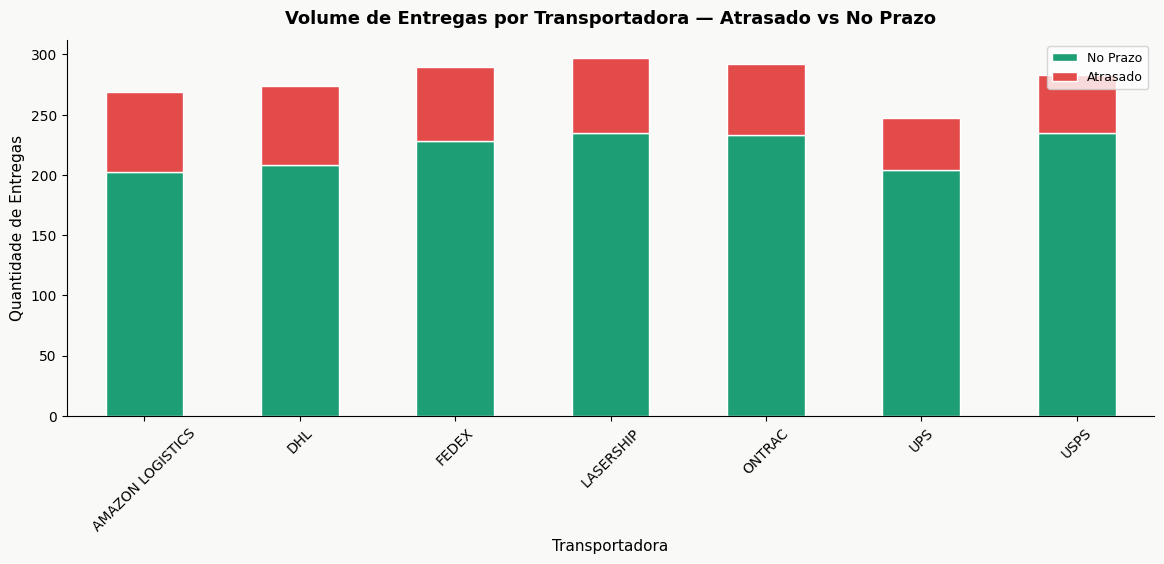

In [75]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

# prepara os dados
dados = (
    df.groupby(['transportadora', 'entregas_atrasadas'])['id_envio']
    .count()
    .unstack(fill_value=0)
    .rename(columns={True: 'Atrasado', False: 'No Prazo'})
)

# gráfico de barras empilhadas
dados[['No Prazo', 'Atrasado']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#1D9E75', '#E24B4A'], edgecolor='white'
)

ax.set_title('Volume de Entregas por Transportadora — Atrasado vs No Prazo',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Transportadora', fontsize=11)
ax.set_ylabel('Quantidade de Entregas', fontsize=11)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout(pad=2)
plt.savefig('volume_transportadora_atraso.png', dpi=150, bbox_inches='tight')
plt.show()

# agrupamento por armazem_origem, entregas_atrasadas e status

In [76]:
df.groupby(['armazem_origem', 'entregas_atrasadas', 'status']).size().sort_index()

armazem_origem  entregas_atrasadas  status   
Warehouse_ATL   False               ATRASADO       3
                                    DEVOLVIDO      3
                                    ENTREGUE     148
                True                ATRASADO      19
                                    ENTREGUE      20
                                                ... 
Warehouse_SF    False               ENTREGUE     154
                True                ATRASADO      18
                                    DEVOLVIDO      1
                                    ENTREGUE      22
                                    PERDIDO        6
Length: 62, dtype: int64

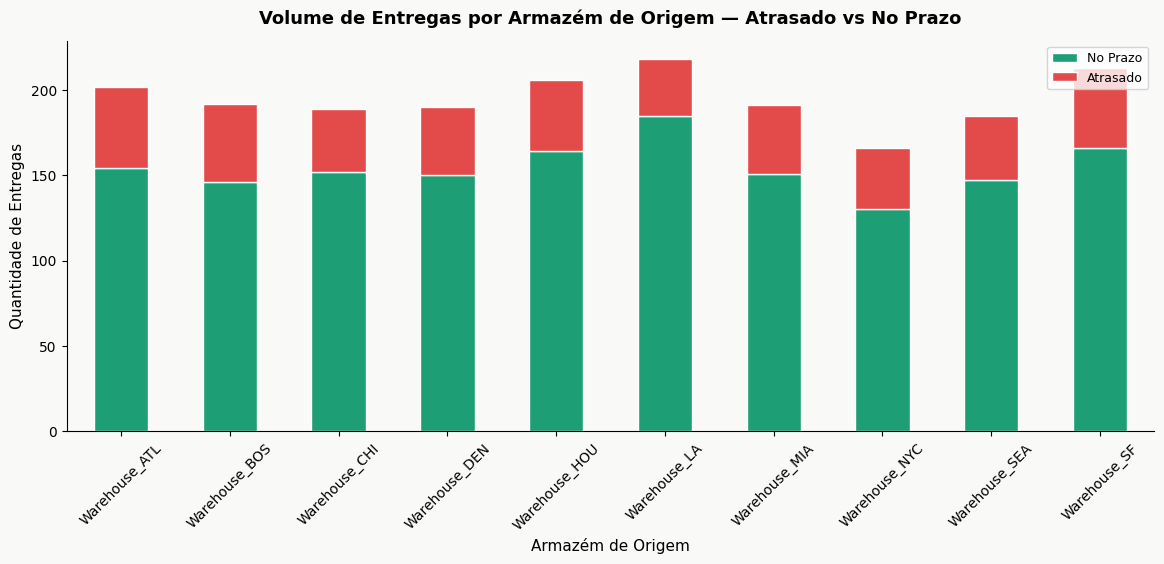

In [77]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

# prepara os dados
dados = (
    df.groupby(['armazem_origem', 'entregas_atrasadas'])['id_envio']
    .count()
    .unstack(fill_value=0)
    .rename(columns={True: 'Atrasado', False: 'No Prazo'})
)

# gráfico de barras empilhadas
dados[['No Prazo', 'Atrasado']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#1D9E75', '#E24B4A'], edgecolor='white'
)

ax.set_title('Volume de Entregas por Armazém de Origem — Atrasado vs No Prazo',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Armazém de Origem', fontsize=11)
ax.set_ylabel('Quantidade de Entregas', fontsize=11)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout(pad=2)
plt.savefig('volume_armazem_atraso.png', dpi=150, bbox_inches='tight')
plt.show()

# reorganizando a ordem das colunas

In [78]:
df = df[['id_envio', 'armazem_origem', 'destino', 'transportadora', 'status',
         'data_envio', 'data_entrega', 'peso_kg', 'custo', 'distancia_milhas',
         'distancia_km', 'dias_transito_original', 'dias_transito_real', 'km_por_dia',
         'p10_km_por_dia', 'p90_dias', 'entregas_atrasadas']]

In [79]:
df.columns

Index(['id_envio', 'armazem_origem', 'destino', 'transportadora', 'status',
       'data_envio', 'data_entrega', 'peso_kg', 'custo', 'distancia_milhas',
       'distancia_km', 'dias_transito_original', 'dias_transito_real',
       'km_por_dia', 'p10_km_por_dia', 'p90_dias', 'entregas_atrasadas'],
      dtype='object')

In [80]:
print(df.dtypes)

id_envio                          object
armazem_origem                    object
destino                           object
transportadora                    object
status                            object
data_envio                datetime64[ns]
data_entrega              datetime64[ns]
peso_kg                          float64
custo                            float64
distancia_milhas                 float64
distancia_km                     float64
dias_transito_original             int64
dias_transito_real               float64
km_por_dia                       float64
p10_km_por_dia                   float64
p90_dias                         float64
entregas_atrasadas                object
dtype: object


# ══════════════════════════════════
# PARTE 3 — ANÁLISE DOS NULOS E CRIAÇÃO DE VARIÁVEL
# ══════════════════════════════════

# fórmula correlação

In [81]:
def cramers_v(column1, column2):
    crosstab = np.array(pd.crosstab(column1, column2))
    chi2 = chi2_contingency(crosstab)[0]
    total = np.sum(crosstab)
    min_dim = min(crosstab.shape) - 1

    # Adicionando tratamento para evitar divisão por zero
    if total * min_dim == 0:
        return 0

    cramer = np.sqrt(chi2 / (total * min_dim))
    return cramer

# matriz de correlação de nulos

a matriz de correlação mede a relação linear entre variáveis numéricas, com valores entre -1 e 1:
- **1** → correlação positiva perfeita (uma sobe, a outra sobe)
- **-1** → correlação negativa perfeita (uma sobe, a outra desce)
- **0** → sem correlação linear

no caso de `df.isnull().corr()`, a correlação é calculada entre os **padrões de nulos**,
ou seja, se os nulos de uma coluna tendem a aparecer juntos com os nulos de outra.

**resultados encontrados:**
- `data_entrega` correlação 1.0 com `dias_transito_real` e `km_por_dia` → dependentes entre si, pois sem data de entrega não é possível calcular as demais
- `custo` correlação -0.017 com `data_entrega` → praticamente zero, nulos independentes
- demais colunas retornam NaN → não possuem nulos, sem variância para calcular correlação

**conclusão:** os nulos de `custo` são independentes dos demais, confirmando erro de registro isolado. já os nulos de `data_entrega`, `dias_transito_real`, `km_por_dia`, `p10_km_por_dia`, `p90_dias` e `entregas_atrasadas` são dependentes entre si, pois uma coluna depende da outra para existir — se não há data de entrega, não há como calcular as demais.

In [82]:
# Matriz de correlação dos nulos
df.isnull().corr()

,id_envio,armazem_origem,destino,transportadora,status,data_envio,data_entrega,peso_kg,custo,distancia_milhas,distancia_km,dias_transito_original,dias_transito_real,km_por_dia,p10_km_por_dia,p90_dias,entregas_atrasadas
id_envio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
armazem_origem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destino,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transportadora,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_envio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_entrega,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,-0.017849,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000
peso_kg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
custo,NaN,NaN,NaN,NaN,NaN,NaN,-0.017849,NaN,1.000000,NaN,NaN,NaN,-0.017849,-0.017849,NaN,NaN,-0.017849
distancia_milhas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# registros com custo e data de entrega nulos simultaneamente

In [83]:
print(df[df['custo'].isna() & df['data_entrega'].isna()].shape[0])

0


# média dos nulos em custo e data_entrega

In [84]:
print(df[['custo', 'data_entrega']].isnull().mean() * 100)

custo           1.966717
data_entrega    1.563288
dtype: float64


# analisando o status dos nulos em custo e data_entrega

In [85]:
print('--- Nulos em custo ---')
print(df[df['custo'].isnull()][['status', 'entregas_atrasadas']].value_counts())

--- Nulos em custo ---
status    entregas_atrasadas
ENTREGUE  False                 29
ATRASADO  True                   5
ENTREGUE  True                   5
Name: count, dtype: int64


# nulos em data_entrega

registros sem `data_entrega` não podem ser classificados pelo comportamento da rota,
pois sem a data de entrega não é possível calcular `dias_transito_real` e consequentemente `km_por_dia`.

por isso, para esses registros:
- `entregas_atrasadas` → NaN

a única informação disponível para análise é o `status` original.

In [86]:
print('\n--- Nulos em data_entrega ---')
print(df[df['data_entrega'].isnull()][['status']].value_counts())


--- Nulos em data_entrega ---
status  
ENTREGUE    26
ATRASADO     5
Name: count, dtype: int64


# criação da variável dados_incompletos

o dataset apresenta nulos em duas colunas, ambos classificados como sem associação com nenhuma variável categórica.

**`data_entrega`** — 31 registros nulos
- 26 com status ENTREGUE → entrega realizada mas data não registrada
- 5 com status ATRASADO → possível entrega sem registro de data

**`custo`** — 39 registros nulos
- 34 com status ENTREGUE → entrega realizada mas custo não registrado
- 5 com status ATRASADO → atraso sem registro de custo


In [87]:
df['dados_incompletos'] = 'COMPLETO'
df.loc[df['custo'].isna(), 'dados_incompletos'] = 'SEM CUSTO'
df.loc[df['data_entrega'].isna(), 'dados_incompletos'] = 'SEM DATA ENTREGA'
df.loc[df['custo'].isna() & df['data_entrega'].isna(), 'dados_incompletos'] = 'SEM CUSTO E DATA'

print(df['dados_incompletos'].value_counts())

dados_incompletos
COMPLETO            1913
SEM CUSTO             39
SEM DATA ENTREGA      31
Name: count, dtype: int64


In [88]:
df_incompletos = df[df['dados_incompletos'] != 'COMPLETO']
print(df_incompletos)

     id_envio armazem_origem        destino    transportadora    status  \
29    SH10030   Warehouse_SF  San Francisco         LASERSHIP  ENTREGUE   
38    SH10039  Warehouse_MIA       New York         LASERSHIP  ENTREGUE   
70    SH10071  Warehouse_CHI        Seattle            ONTRAC  ENTREGUE   
96    SH10097  Warehouse_MIA        Atlanta  AMAZON LOGISTICS  ENTREGUE   
100   SH10101  Warehouse_DEN          Miami         LASERSHIP  ENTREGUE   
...       ...            ...            ...               ...       ...   
1871  SH11888  Warehouse_NYC  San Francisco  AMAZON LOGISTICS  ENTREGUE   
1882  SH11899  Warehouse_SEA    Los Angeles              USPS  ENTREGUE   
1915  SH11932  Warehouse_BOS         Denver               DHL  ENTREGUE   
1926  SH11943  Warehouse_SEA        Chicago              USPS  ENTREGUE   
1982  SH11999  Warehouse_MIA       Portland            ONTRAC  ENTREGUE   

     data_envio data_entrega  peso_kg   custo  distancia_milhas  distancia_km  \
29   2023-11-04   

In [89]:
df.columns

Index(['id_envio', 'armazem_origem', 'destino', 'transportadora', 'status',
       'data_envio', 'data_entrega', 'peso_kg', 'custo', 'distancia_milhas',
       'distancia_km', 'dias_transito_original', 'dias_transito_real',
       'km_por_dia', 'p10_km_por_dia', 'p90_dias', 'entregas_atrasadas',
       'dados_incompletos'],
      dtype='object')

In [90]:
print(df.dtypes)

id_envio                          object
armazem_origem                    object
destino                           object
transportadora                    object
status                            object
data_envio                datetime64[ns]
data_entrega              datetime64[ns]
peso_kg                          float64
custo                            float64
distancia_milhas                 float64
distancia_km                     float64
dias_transito_original             int64
dias_transito_real               float64
km_por_dia                       float64
p10_km_por_dia                   float64
p90_dias                         float64
entregas_atrasadas                object
dados_incompletos                 object
dtype: object


# registros sem classificação de atraso — nulos em entregas_atrasadas

registros com `entregas_atrasadas` nulo são aqueles que não puderam ser classificados
pela função `classificar_por_rota`, pois não possuem `data_entrega`.

sem `data_entrega` → sem `dias_transito_real` → sem `km_por_dia` → sem classificação.`

In [91]:
print(df[df['entregas_atrasadas'].isna()][['status', 'data_entrega', 'dias_transito_real', 'custo', 'dados_incompletos']].to_string())

        status data_entrega  dias_transito_real   custo dados_incompletos
29    ENTREGUE          NaT                 NaN  109.33  SEM DATA ENTREGA
38    ENTREGUE          NaT                 NaN  284.81  SEM DATA ENTREGA
96    ENTREGUE          NaT                 NaN  259.98  SEM DATA ENTREGA
108   ENTREGUE          NaT                 NaN   73.12  SEM DATA ENTREGA
151   ENTREGUE          NaT                 NaN  362.11  SEM DATA ENTREGA
202   ENTREGUE          NaT                 NaN   65.87  SEM DATA ENTREGA
256   ATRASADO          NaT                 NaN  358.31  SEM DATA ENTREGA
316   ENTREGUE          NaT                 NaN   53.22  SEM DATA ENTREGA
342   ENTREGUE          NaT                 NaN   69.79  SEM DATA ENTREGA
439   ENTREGUE          NaT                 NaN  171.21  SEM DATA ENTREGA
462   ATRASADO          NaT                 NaN   35.59  SEM DATA ENTREGA
589   ENTREGUE          NaT                 NaN   77.76  SEM DATA ENTREGA
628   ENTREGUE          NaT           

# nulos por transportadora e armazem

In [92]:
# nulos por transportadora
print('--- Nulos por transportadora ---')
print(df.groupby('transportadora')[['custo', 'data_entrega']].apply(lambda x: x.isnull().sum()))

print()

# nulos por armazem
print('--- Nulos por armazem ---')
print(df.groupby('armazem_origem')[['custo', 'data_entrega']].apply(lambda x: x.isnull().sum()))

--- Nulos por transportadora ---
                  custo  data_entrega
transportadora                       
AMAZON LOGISTICS      6             2
DHL                   5             6
FEDEX                 1             1
LASERSHIP             7             5
ONTRAC                4             5
UPS                   5             9
USPS                 11             3

--- Nulos por armazem ---
                custo  data_entrega
armazem_origem                     
Warehouse_ATL       3             1
Warehouse_BOS       5             0
Warehouse_CHI       5             6
Warehouse_DEN       6             5
Warehouse_HOU       4             5
Warehouse_LA        3             0
Warehouse_MIA       2             8
Warehouse_NYC       6             1
Warehouse_SEA       3             4
Warehouse_SF        2             1


# gráfico mostrando os nulos

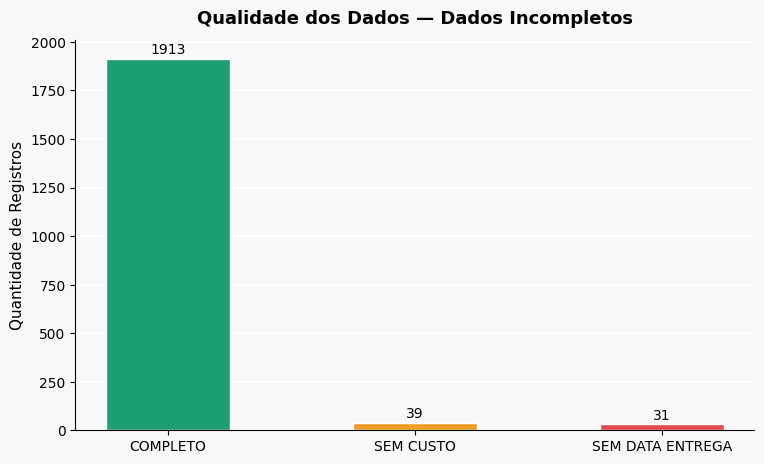

In [93]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#f9f9f8')

contagem = df['dados_incompletos'].value_counts()

cores = {
    'COMPLETO': '#1D9E75',
    'SEM CUSTO': '#EF9F27',
    'SEM DATA ENTREGA': '#E24B4A',
    'SEM CUSTO E DATA': '#7F77DD'
}

bars = ax.bar(contagem.index, contagem.values,
              color=[cores[c] for c in contagem.index],
              edgecolor='white', width=0.5)

for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_title('Qualidade dos Dados — Dados Incompletos', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Quantidade de Registros', fontsize=11)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

plt.tight_layout(pad=2)
plt.savefig('dados_incompletos.png', dpi=150, bbox_inches='tight')
plt.show()

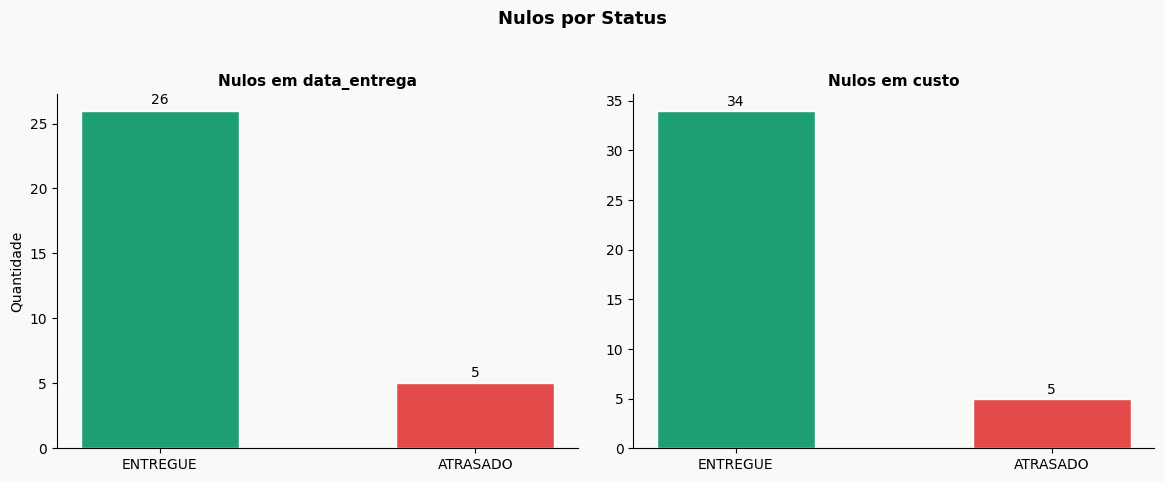

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#f9f9f8')
fig.suptitle('Nulos por Status', fontsize=13, fontweight='bold')

# nulos em data_entrega
nulos_data = df[df['data_entrega'].isna()]['status'].value_counts()
axes[0].bar(nulos_data.index, nulos_data.values,
            color=['#1D9E75', '#E24B4A'], edgecolor='white', width=0.5)
axes[0].set_title('Nulos em data_entrega', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Quantidade', fontsize=10)
axes[0].set_facecolor('#f9f9f8')
axes[0].spines[['top', 'right']].set_visible(False)
for bar, val in zip(axes[0].patches, nulos_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=10)

# nulos em custo
nulos_custo = df[df['custo'].isna()]['status'].value_counts()
axes[1].bar(nulos_custo.index, nulos_custo.values,
            color=['#1D9E75', '#E24B4A'], edgecolor='white', width=0.5)
axes[1].set_title('Nulos em custo', fontsize=11, fontweight='bold')
axes[1].set_facecolor('#f9f9f8')
axes[1].spines[['top', 'right']].set_visible(False)
for bar, val in zip(axes[1].patches, nulos_custo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=10)

plt.tight_layout(pad=2)
plt.savefig('nulos_por_status.png', dpi=150, bbox_inches='tight')
plt.show()

# gráfico de nulos por transportadora e armazem

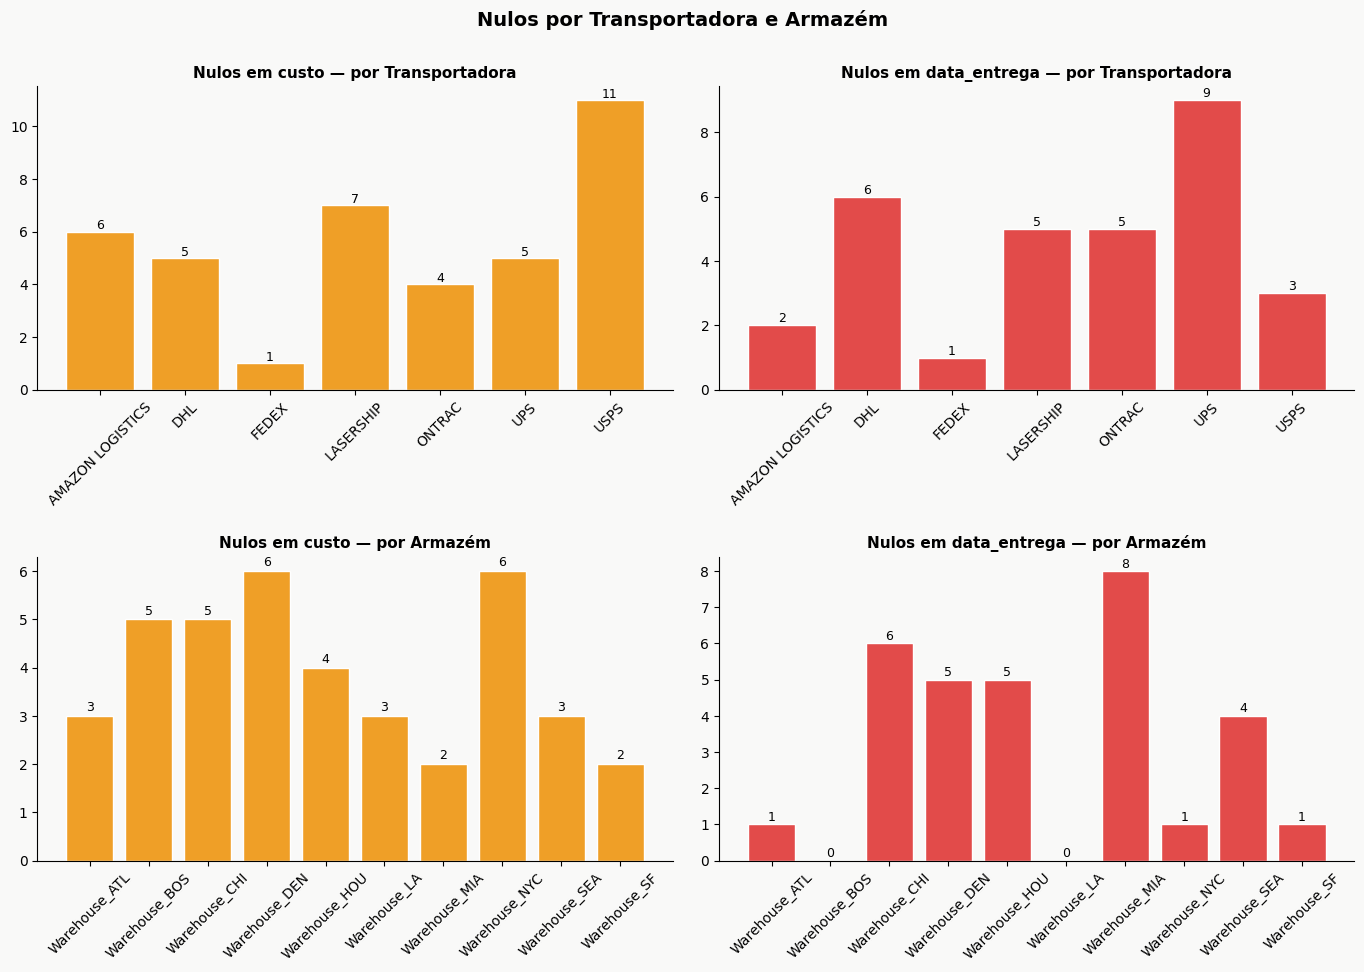

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#f9f9f8')
fig.suptitle('Nulos por Transportadora e Armazém', fontsize=14, fontweight='bold')

# nulos em custo por transportadora
nulos_custo_transp = df.groupby('transportadora')['custo'].apply(lambda x: x.isnull().sum())
axes[0, 0].bar(nulos_custo_transp.index, nulos_custo_transp.values, color='#EF9F27', edgecolor='white')
axes[0, 0].set_title('Nulos em custo — por Transportadora', fontsize=11, fontweight='bold')
axes[0, 0].set_facecolor('#f9f9f8')
axes[0, 0].spines[['top', 'right']].set_visible(False)
axes[0, 0].tick_params(axis='x', labelrotation=45)
for bar, val in zip(axes[0, 0].patches, nulos_custo_transp.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', fontsize=9)

# nulos em data_entrega por transportadora
nulos_data_transp = df.groupby('transportadora')['data_entrega'].apply(lambda x: x.isnull().sum())
axes[0, 1].bar(nulos_data_transp.index, nulos_data_transp.values, color='#E24B4A', edgecolor='white')
axes[0, 1].set_title('Nulos em data_entrega — por Transportadora', fontsize=11, fontweight='bold')
axes[0, 1].set_facecolor('#f9f9f8')
axes[0, 1].spines[['top', 'right']].set_visible(False)
axes[0, 1].tick_params(axis='x', labelrotation=45)
for bar, val in zip(axes[0, 1].patches, nulos_data_transp.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', fontsize=9)

# nulos em custo por armazem
nulos_custo_arm = df.groupby('armazem_origem')['custo'].apply(lambda x: x.isnull().sum())
axes[1, 0].bar(nulos_custo_arm.index, nulos_custo_arm.values, color='#EF9F27', edgecolor='white')
axes[1, 0].set_title('Nulos em custo — por Armazém', fontsize=11, fontweight='bold')
axes[1, 0].set_facecolor('#f9f9f8')
axes[1, 0].spines[['top', 'right']].set_visible(False)
axes[1, 0].tick_params(axis='x', labelrotation=45)
for bar, val in zip(axes[1, 0].patches, nulos_custo_arm.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', fontsize=9)

# nulos em data_entrega por armazem
nulos_data_arm = df.groupby('armazem_origem')['data_entrega'].apply(lambda x: x.isnull().sum())
axes[1, 1].bar(nulos_data_arm.index, nulos_data_arm.values, color='#E24B4A', edgecolor='white')
axes[1, 1].set_title('Nulos em data_entrega — por Armazém', fontsize=11, fontweight='bold')
axes[1, 1].set_facecolor('#f9f9f8')
axes[1, 1].spines[['top', 'right']].set_visible(False)
axes[1, 1].tick_params(axis='x', labelrotation=45)
for bar, val in zip(axes[1, 1].patches, nulos_data_arm.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', fontsize=9)

plt.tight_layout(pad=2)
plt.savefig('nulos_transportadora_armazem.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════ #

# quantidade colunas em linhas após a criação das variáveis

In [96]:
df.shape

(1983, 18)

# ══════════════════════════════════
# PARTE 4 — ANÁLISES DOS DADOS
# ══════════════════════════════════

# análise de estatísticas descritivas

calculadas média, mínimo, máximo e percentil 90 das variáveis principais, sem criação de colunas adicionais no df.

considera-se somente colunas numéricas.

os cálculos excluem automaticamente os nulos presentes em `custo`.

**resultados:**

| Variável           | Média   | Mínimo | Máximo  | Percentil 90 |
|--------------------|---------|--------|---------|--------------|
| custo              | 205.15  | 17.89  | 6562.21 | 324.85       |
| peso_kg            | 30.22   | 0.00   | 5404.20 | 51.96        |
| distancia_km       | 2052.78 | 162.54 | 4021.74 | 3621.02      |
| dias_transito_real | 4.90    | 1.00   | 20.00   | 8.00         |

**insights identificados:**
- `custo` apresenta alta variabilidade: média de 205 mas máximo de 6562
- `peso_kg` também: média de 30kg mas máximo de 5404kg — envios muito discrepantes
- `distancia_km` varia de 162.54 a 4021.74 km — amplitude grande e bem distribuída
- `dias_transito_real` chega a 20 dias — percentil 90 de 8 dias indica que 90% das entregas chegam em até 8 dias

# sobre a análise de outliers

a análise de outliers não foi realizada separadamente pois:

- as **estatísticas descritivas** já evidenciam os valores extremos das variáveis principais
- a **classificação por comportamento de rota** (P90 de dias e P10 de km/dia) já trata os desvios operacionais de forma mais precisa, considerando o padrão de cada rota individualmente

realizar uma análise de outliers global seria redundante e menos precisa do que a lógica já aplicada.

In [97]:
# Estatísticas descritivas das variáveis principais
variaveis = ['custo', 'peso_kg', 'distancia_km', 'dias_transito_real']

estatisticas = df[variaveis].agg(['mean', 'min', 'max']).T

# Adiciona percentil 90
estatisticas['percentil_90'] = df[variaveis].quantile(0.9)

print(estatisticas.round(2))

                       mean     min      max  percentil_90
custo                205.15   17.89  6562.21        324.85
peso_kg               30.22    0.00  5404.20         51.96
distancia_km        2052.78  162.54  4021.74       3621.02
dias_transito_real     4.90    1.00    20.00          8.00


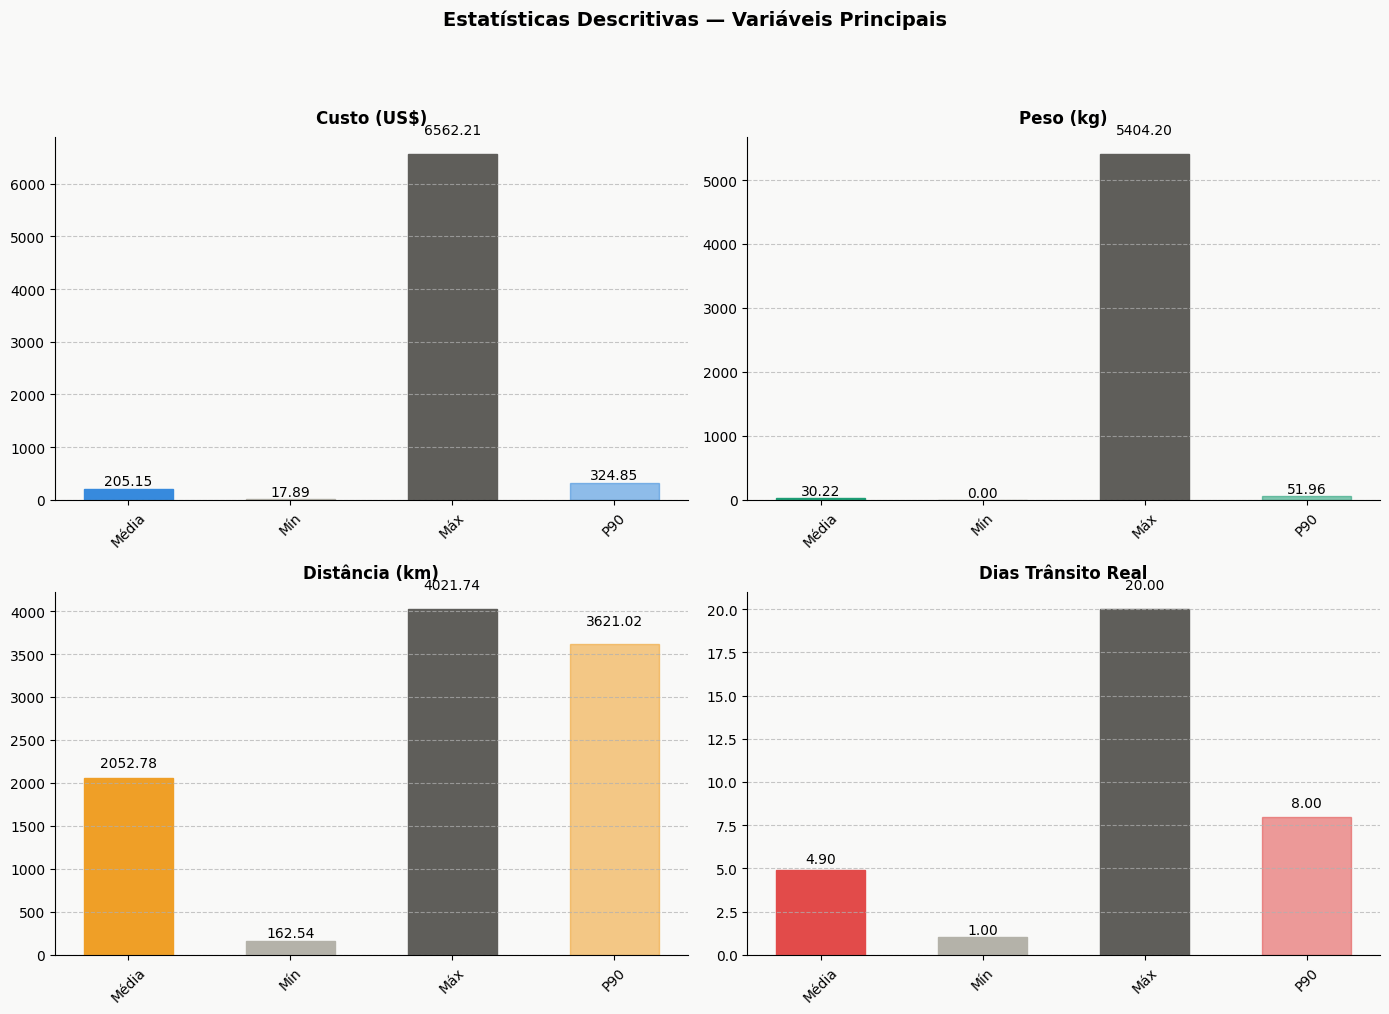

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#f9f9f8')
fig.suptitle('Estatísticas Descritivas — Variáveis Principais', fontsize=14, fontweight='bold', y=1.01)

variaveis = ['custo', 'peso_kg', 'distancia_km', 'dias_transito_real']
titulos   = ['Custo (US$)', 'Peso (kg)', 'Distância (km)', 'Dias Trânsito Real']
cor_barra = ['#378ADD', '#1D9E75', '#EF9F27', '#E24B4A']

for ax, var, titulo, cor in zip(axes.flat, variaveis, titulos, cor_barra):
    row = estatisticas.loc[var]
    metricas = ['mean', 'min', 'max', 'percentil_90']
    labels   = ['Média', 'Mín', 'Máx', 'P90']
    valores  = [row[m] for m in metricas]

    bars = ax.bar(labels, valores, color=[cor, '#B4B2A9', '#888780', cor + 'aa'],
                  edgecolor='white', width=0.55)

    bars[0].set_color(cor)
    bars[1].set_color('#B4B2A9')
    bars[2].set_color('#5F5E5A')
    bars[3].set_color(cor)
    bars[3].set_alpha(0.55)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (bar.get_height() * 0.05),
                f'{val:.2f}', ha='center', va='bottom')

    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_facecolor('#f9f9f8')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('estatisticas_descritivas.png', dpi=150, bbox_inches='tight')
plt.show()

# taxa de atraso por transportadora
agrupamento por `transportadora` para calcular o desempenho de cada carrier em relação aos atrasos.
métricas calculadas:

* `total_envios` → total de envios por transportadora
* `total_atrasados` → quantidade de envios classificados como ATRASADO
* `taxa_atraso` → percentual de envios atrasados sobre o total

insights identificados:

* Amazon Logistics apresenta a maior taxa de atraso (24.72%), apesar de operar rede própria
* DHL aparece em segundo lugar com 23.57%
* USPS é a transportadora mais confiável com menor taxa de atraso (16.78%)

In [99]:
taxa_atraso = (
    df.groupby('transportadora')
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('entregas_atrasadas', 'sum')
    )
    .assign(taxa_atraso=lambda x: x['total_atrasados'] / x['total_envios'] * 100)
    .sort_values('taxa_atraso', ascending=False)
)

print(taxa_atraso)

                  total_envios total_atrasados taxa_atraso
transportadora                                            
AMAZON LOGISTICS           271              67   24.723247
DHL                        280              66   23.571429
FEDEX                      291              62   21.305842
LASERSHIP                  302              62   20.529801
ONTRAC                     297              59    19.86532
UPS                        256              43   16.796875
USPS                       286              48   16.783217


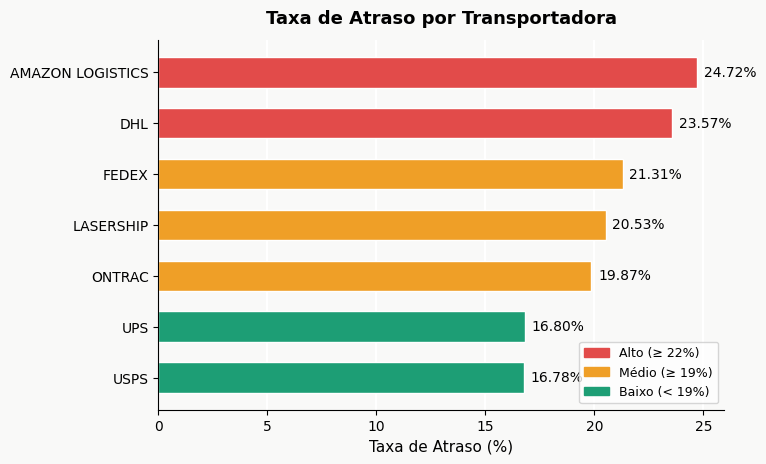

In [100]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#f9f9f8')

transportadoras = taxa_atraso.index.tolist()
taxas = taxa_atraso['taxa_atraso'].tolist()

cores = ['#E24B4A' if t >= 22 else '#EF9F27' if t >= 19 else '#1D9E75' for t in taxas]

bars = ax.barh(transportadoras, taxas, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Taxa de Atraso (%)', fontsize=11)
ax.set_title('Taxa de Atraso por Transportadora', fontsize=13, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 22%)')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio (≥ 19%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 19%)')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso.png', dpi=150, bbox_inches='tight')
plt.show()

# taxa de atraso por rota

agrupamento por `armazem_origem` e `destino` para calcular o desempenho de cada rota em relação aos atrasos.

**métricas calculadas:**
- `total_envios` → total de envios por rota
- `total_atrasados` → quantidade de envios classificados como ATRASADO
- `taxa_atraso` → percentual de envios atrasados sobre o total

**insights identificados:**
- Warehouse_ATL → Detroit, Warehouse_HOU → Portland e Warehouse_SF → Chicago lideram empatadas com 41.67%
- Warehouse_CHI → New York aparece em seguida com 40.00% — mas com apenas 5 envios
- Warehouse_BOS → Miami e Warehouse_CHI → Dallas fecham o top 10 com 33.33%

**observação:** rotas com poucos envios devem ser interpretadas com cautela, pois cada atraso representa uma fatia maior do total.

In [101]:
taxa_atraso_rota = (
    df.groupby(['armazem_origem', 'destino'])
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('entregas_atrasadas', 'sum')
    )
    .assign(taxa_atraso=lambda x: (x['total_atrasados'] / x['total_envios'] * 100))
    .sort_values('taxa_atraso', ascending=False)
    .head(10)
)

print(taxa_atraso_rota)

                            total_envios total_atrasados taxa_atraso
armazem_origem destino                                              
Warehouse_ATL  Detroit                12               5   41.666667
Warehouse_HOU  Portland               12               5   41.666667
Warehouse_SF   Chicago                12               5   41.666667
Warehouse_CHI  New York                5               2        40.0
Warehouse_BOS  Houston                13               5   38.461538
Warehouse_ATL  Denver                 13               5   38.461538
Warehouse_MIA  Houston                 8               3        37.5
Warehouse_NYC  Minneapolis            14               5   35.714286
Warehouse_CHI  Dallas                  6               2   33.333333
Warehouse_BOS  Miami                  12               4   33.333333


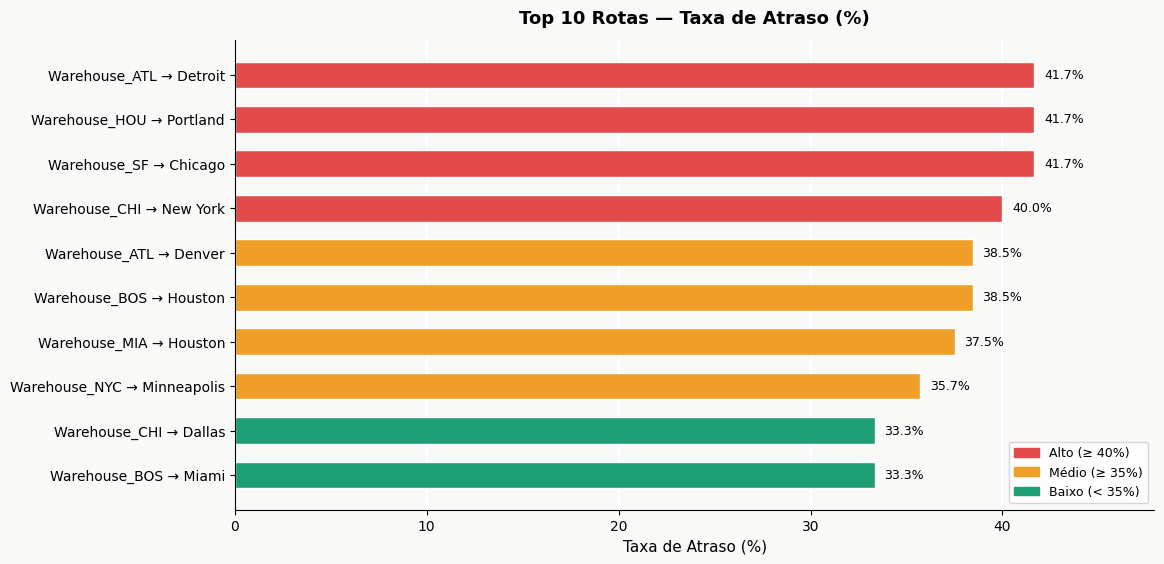

In [102]:
taxa_atraso_rota['taxa_atraso'] = taxa_atraso_rota['taxa_atraso'].astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

taxa_atraso_rota_plot = taxa_atraso_rota.nlargest(10, 'taxa_atraso').copy()
taxa_atraso_rota_plot['rota'] = (
    taxa_atraso_rota_plot.index.get_level_values('armazem_origem') + ' → ' +
    taxa_atraso_rota_plot.index.get_level_values('destino')
)
taxa_atraso_rota_plot = taxa_atraso_rota_plot.sort_values('taxa_atraso', ascending=True)

rotas = taxa_atraso_rota_plot['rota'].tolist()
taxas = taxa_atraso_rota_plot['taxa_atraso'].tolist()

cores = ['#E24B4A' if t >= 40 else '#EF9F27' if t >= 35 else '#1D9E75' for t in taxas]

bars = ax.barh(rotas, taxas, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Taxa de Atraso (%)', fontsize=11)
ax.set_title('Top 10 Rotas — Taxa de Atraso (%)', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlim(0, max(taxas) * 1.15)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 40%)')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio (≥ 35%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 35%)')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso_rotas.png', dpi=150, bbox_inches='tight')
plt.show()

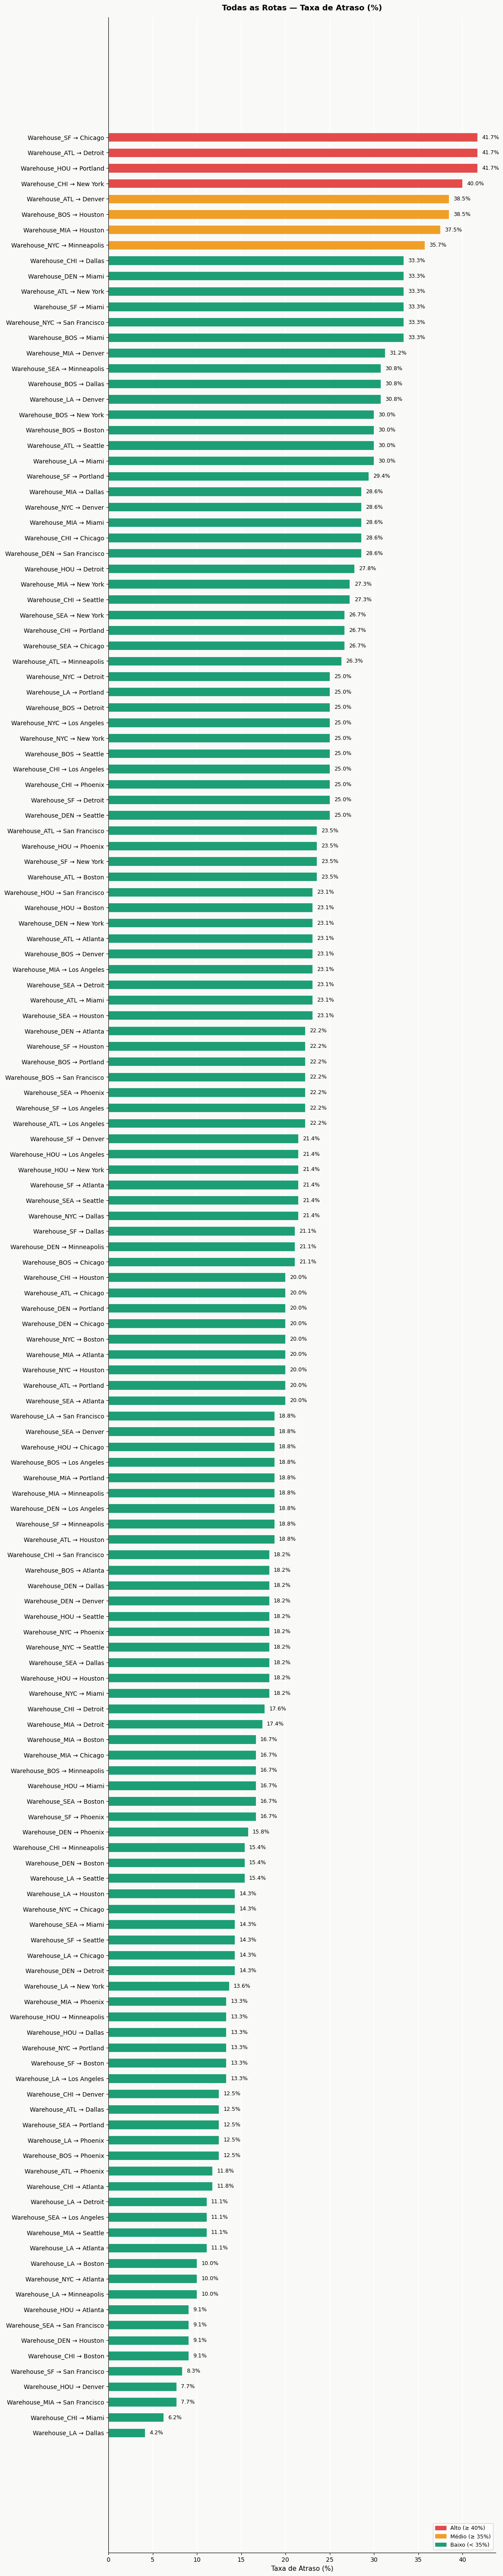

In [103]:
# Calcula todas as rotas sem head(10)
taxa_atraso_todas = (
    df.groupby(['armazem_origem', 'destino'])
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('entregas_atrasadas', 'sum')
    )
    .assign(taxa_atraso=lambda x: x['total_atrasados'] / x['total_envios'] * 100)
    .sort_values('taxa_atraso', ascending=True)
)

taxa_atraso_todas['rota'] = (
    taxa_atraso_todas.index.get_level_values('armazem_origem') + ' → ' +
    taxa_atraso_todas.index.get_level_values('destino')
)

rotas = taxa_atraso_todas['rota'].tolist()
taxas = taxa_atraso_todas['taxa_atraso'].tolist()

fig, ax = plt.subplots(figsize=(12, len(rotas) * 0.4))
fig.patch.set_facecolor('#f9f9f8')

cores = ['#E24B4A' if t >= 40 else '#EF9F27' if t >= 35 else '#1D9E75' for t in taxas]

bars = ax.barh(rotas, taxas, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Taxa de Atraso (%)', fontsize=11)
ax.set_title('Todas as Rotas — Taxa de Atraso (%)', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 40%)')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio (≥ 35%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 35%)')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso_todas_rotas.png', dpi=150, bbox_inches='tight')
plt.show()

# taxa de atraso por transportadora e rota

cruzamento entre `transportadora`, `armazem_origem` e `destino` para identificar
as combinações mais críticas em relação aos atrasos.

**filtro aplicado:** mínimo de 5 envios por combinação para garantir significância estatística.

**métricas calculadas:**
- `total_envios` → total de envios por combinação transportadora + rota
- `total_atrasados` → quantidade de envios classificados como ATRASADO
- `taxa_atraso` → percentual de envios atrasados sobre o total

**insights identificados:**
- Amazon Logistics | Warehouse_BOS → Portland lidera com 50% de taxa de atraso (3 de 6 envios)
- Amazon Logistics | Warehouse_CHI → Los Angeles, Lasership | Warehouse_SF → Dallas e DHL | Warehouse_BOS → Houston e Warehouse_HOU → Chicago empatam em segundo com 40%
- DHL e Lasership aparecem múltiplas vezes no top 10
- nenhuma combinação atingiu 100% de atraso com volume relevante — o filtro de mínimo 5 envios garantiu resultados mais confiáveis

In [104]:
taxa_atraso_transp_rota = (
    df.groupby(['transportadora', 'armazem_origem', 'destino'])
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('entregas_atrasadas', 'sum')
    )
    .assign(taxa_atraso=lambda x: x['total_atrasados'] / x['total_envios'] * 100)
    .query('total_envios >= 5')
    .sort_values('taxa_atraso', ascending=False)
)

print(taxa_atraso_transp_rota.head(10).to_string())

                                             total_envios total_atrasados taxa_atraso
transportadora   armazem_origem destino                                              
AMAZON LOGISTICS Warehouse_BOS  Portland                6               3        50.0
                 Warehouse_CHI  Los Angeles             5               2        40.0
LASERSHIP        Warehouse_SF   Dallas                  5               2        40.0
DHL              Warehouse_BOS  Houston                 5               2        40.0
                 Warehouse_HOU  Chicago                 5               2        40.0
LASERSHIP        Warehouse_SF   Chicago                 6               2   33.333333
DHL              Warehouse_ATL  Chicago                 6               2   33.333333
UPS              Warehouse_BOS  Los Angeles             6               2   33.333333
DHL              Warehouse_LA   Los Angeles             6               2   33.333333
AMAZON LOGISTICS Warehouse_DEN  Phoenix               

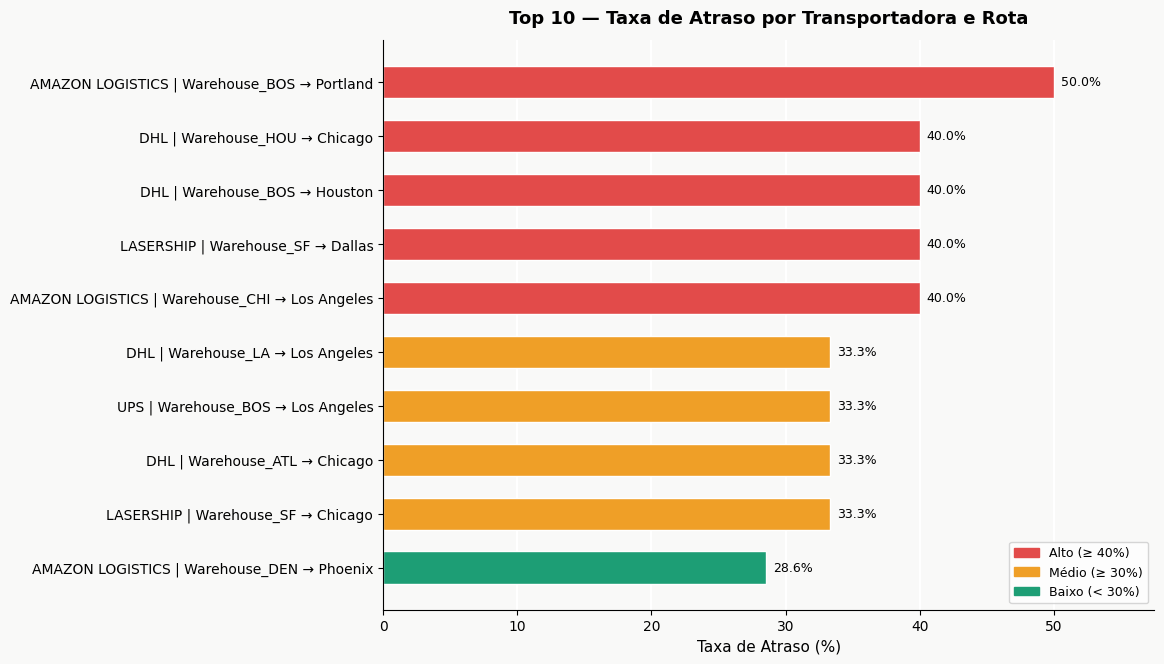

In [105]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f9f9f8')

plot = taxa_atraso_transp_rota.head(10).copy()
plot['rota'] = plot.index.get_level_values('transportadora') + ' | ' + \
               plot.index.get_level_values('armazem_origem') + ' → ' + \
               plot.index.get_level_values('destino')
plot = plot.sort_values('taxa_atraso', ascending=True)

rotas  = plot['rota'].tolist()
taxas  = plot['taxa_atraso'].tolist()

cores = ['#E24B4A' if t >= 40 else '#EF9F27' if t >= 30 else '#1D9E75' for t in taxas]

bars = ax.barh(rotas, taxas, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Taxa de Atraso (%)', fontsize=11)
ax.set_title('Top 10 — Taxa de Atraso por Transportadora e Rota', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlim(0, max(taxas) * 1.15)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 40%)')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio (≥ 30%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 30%)')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso_transp_rota.png', dpi=150, bbox_inches='tight')
plt.show()

# taxa de atraso por destino

agrupamento por destino para identificar as cidades com maior proporção de entregas atrasadas.

**métricas calculadas:**
- `total_envios` → total de envios por destino
- `total_atrasados` → quantidade de envios classificados como ATRASADO
- `taxa_atraso` → percentual de envios atrasados sobre o total

**insights identificados:**
- New York é o destino mais crítico com 23.93% de taxa de atraso
- Miami, Detroit e Portland também ultrapassam 23%
- Chicago tem o maior volume de envios (154) com taxa de 21.43%
- Phoenix é o destino mais confiável com 16.44% e 146 envios

In [106]:
taxa_atraso_destino = (
    df.groupby('destino')
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('entregas_atrasadas', 'sum')
    )
    .assign(taxa_atraso=lambda x: x['total_atrasados'] / x['total_envios'] * 100)
    .sort_values('taxa_atraso', ascending=False)
)

print(taxa_atraso_destino)

               total_envios total_atrasados taxa_atraso
destino                                                
New York                117              28   23.931624
Miami                   121              28   23.140496
Detroit                 139              32   23.021583
Portland                145              33   22.758621
Denver                  140              31   22.142857
Houston                 125              27        21.6
Chicago                 154              33   21.428571
Minneapolis             147              31   21.088435
Seattle                 109              22   20.183486
Los Angeles             125              25        20.0
San Francisco           128              25    19.53125
Boston                  118              21    17.79661
Dallas                  136              24   17.647059
Atlanta                 133              23   17.293233
Phoenix                 146              24   16.438356


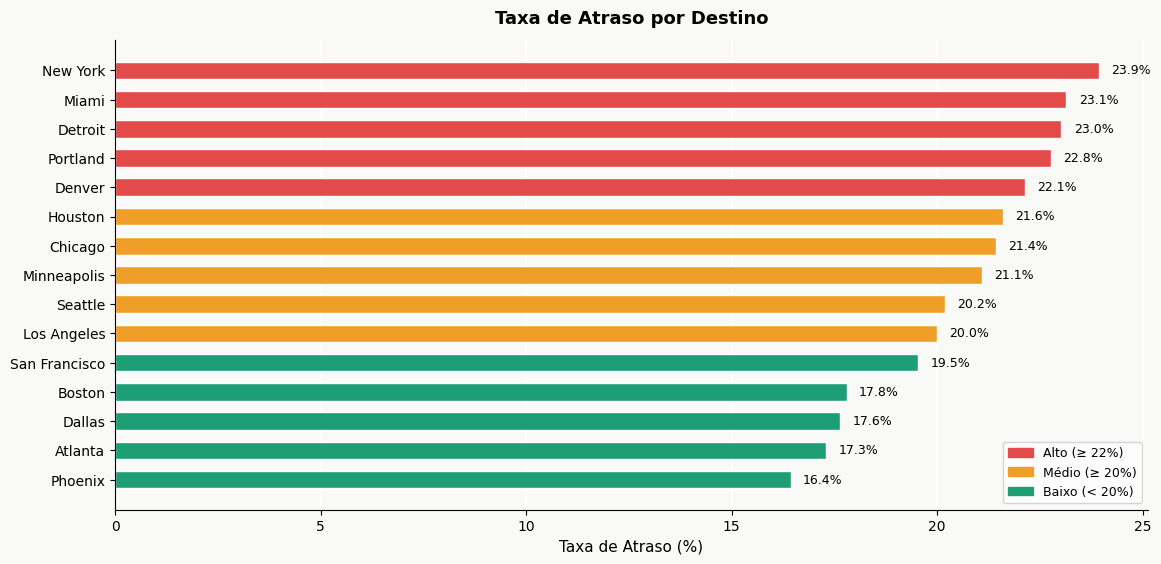

In [107]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

destinos = taxa_atraso_destino.index.tolist()
taxas = taxa_atraso_destino['taxa_atraso'].tolist()

cores = ['#E24B4A' if t >= 22 else '#EF9F27' if t >= 20 else '#1D9E75' for t in taxas]

bars = ax.barh(destinos, taxas, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Taxa de Atraso (%)', fontsize=11)
ax.set_title('Taxa de Atraso por Destino', fontsize=13, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, taxas):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto (≥ 22%)')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio (≥ 20%)')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo (< 20%)')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('taxa_atraso_destino.png', dpi=150, bbox_inches='tight')
plt.show()

# análise de custo por km

calculada a métrica `custo_por_km` diretamente no agrupamento, sem criação
de coluna adicional no df, dividindo o custo pelo total de km percorridos.

**top 3 rotas com maior custo por km:**
- Warehouse_LA para San Francisco: 0.29 por km (maior custo - rota curta com custo fixo alto)
- Warehouse_NYC para Boston: 0.19 por km
- Warehouse_HOU para Detroit: 0.18 por km

**insight identificado**

- rotas mais curtas tendem a apresentar maior custo por km, pois o custo fixo
do envio é diluído em menos quilômetros.
- Warehouse_LA para San Francisco se
destaca com custo quase o dobro da segunda colocada, sugerindo ineficiência
logística ou tarifa diferenciada nesse trajeto.

In [108]:
# media de custo por km - top 10
custo_por_km_rota = (
    df[(df['distancia_km'] > 0) & (df['custo'].notna())] # excluir distancia menor que o e nulos em custo
    .groupby(['armazem_origem', 'destino'])
    .apply(lambda x: (x['custo'] / x['distancia_km']).mean())
    .reset_index(name='media_custo_por_km')
    .sort_values('media_custo_por_km', ascending=False)
)

print(custo_por_km_rota.head(10))

    armazem_origem        destino  media_custo_por_km
88    Warehouse_LA  San Francisco            0.291714
106  Warehouse_NYC         Boston            0.193116
65   Warehouse_HOU        Detroit            0.185988
32   Warehouse_CHI        Chicago            0.171439
7    Warehouse_ATL    Los Angeles            0.160039
35   Warehouse_CHI        Detroit            0.157510
82    Warehouse_LA    Los Angeles            0.140521
96   Warehouse_MIA        Houston            0.137857
122  Warehouse_SEA        Chicago            0.137545
76    Warehouse_LA         Boston            0.136434


/tmp/ipykernel_18507/2690066816.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['custo'] / x['distancia_km']).mean())


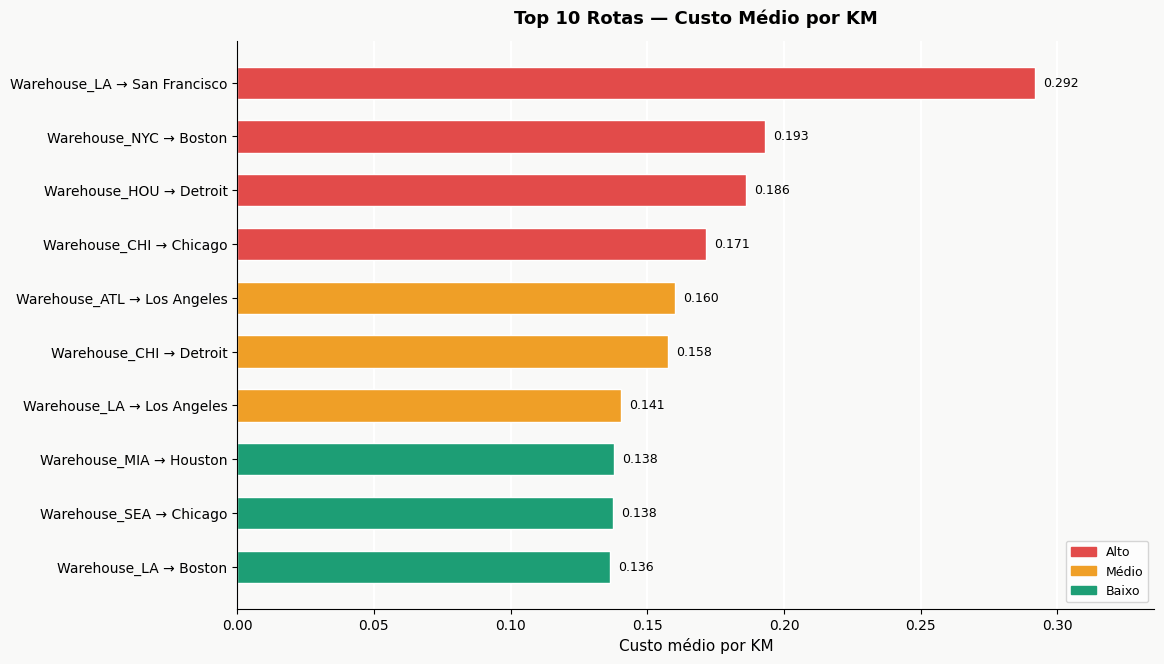

In [109]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f9f9f8')

custo_plot = custo_por_km_rota.nlargest(10, 'media_custo_por_km').copy()
custo_plot['rota'] = custo_plot['armazem_origem'] + ' → ' + custo_plot['destino']
custo_plot = custo_plot.sort_values('media_custo_por_km', ascending=True)

rotas  = custo_plot['rota'].tolist()
custos = custo_plot['media_custo_por_km'].tolist()

def cor(i, total):
    t = i / (total - 1)
    if t >= 0.66: return '#E24B4A'
    if t >= 0.33: return '#EF9F27'
    return '#1D9E75'

cores = [cor(i, len(custos)) for i in range(len(custos))]

bars = ax.barh(rotas, custos, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Custo médio por KM', fontsize=11)
ax.set_title('Top 10 Rotas — Custo Médio por KM', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, custos):
    ax.text(val + max(custos) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlim(0, max(custos) * 1.15)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('custo_por_km_rotas.png', dpi=150, bbox_inches='tight')
plt.show()

# análise de custo por peso

- métrica `custo_por_kg` calculada diretamente no agrupamento, sem criação de coluna adicional no df
- envios com peso igual a zero foram excluídos para evitar divisão por zero

**top 3 rotas com maior custo por kg:**
- Warehouse_HOU → Seattle: 115.69/kg (maior custo)
- Warehouse_ATL → Atlanta: 84.41/kg
- Warehouse_MIA → San Francisco: 78.51/kg

**insight:** Warehouse_HOU → Seattle se destaca com custo por kg quase o dobro da segunda colocada,
sugerindo que envios pesados em rotas longas representam o maior impacto financeiro para a operação.

In [110]:
# média de custo por peso - top 10
custo_por_kg = (
    df[(df['peso_kg'] > 0) & (df['custo'].notna())] # tira o único peso zero que tem e exclui os nulos em custo
    .groupby(['armazem_origem', 'destino'])
    .apply(lambda x: (x['custo'] / x['peso_kg']).mean())
    .reset_index(name='media_custo_por_kg')
    .sort_values('media_custo_por_kg', ascending=False)
)

print(custo_por_kg.head(10))

    armazem_origem        destino  media_custo_por_kg
74   Warehouse_HOU        Seattle          115.685876
0    Warehouse_ATL        Atlanta           84.409757
103  Warehouse_MIA  San Francisco           78.505482
98   Warehouse_MIA          Miami           69.709973
21   Warehouse_BOS        Houston           56.620921
65   Warehouse_HOU        Detroit           41.734202
69   Warehouse_HOU    Minneapolis           35.133860
89    Warehouse_LA        Seattle           34.996405
23   Warehouse_BOS          Miami           23.446208
118  Warehouse_NYC  San Francisco           18.837008


/tmp/ipykernel_18507/3988392031.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['custo'] / x['peso_kg']).mean())


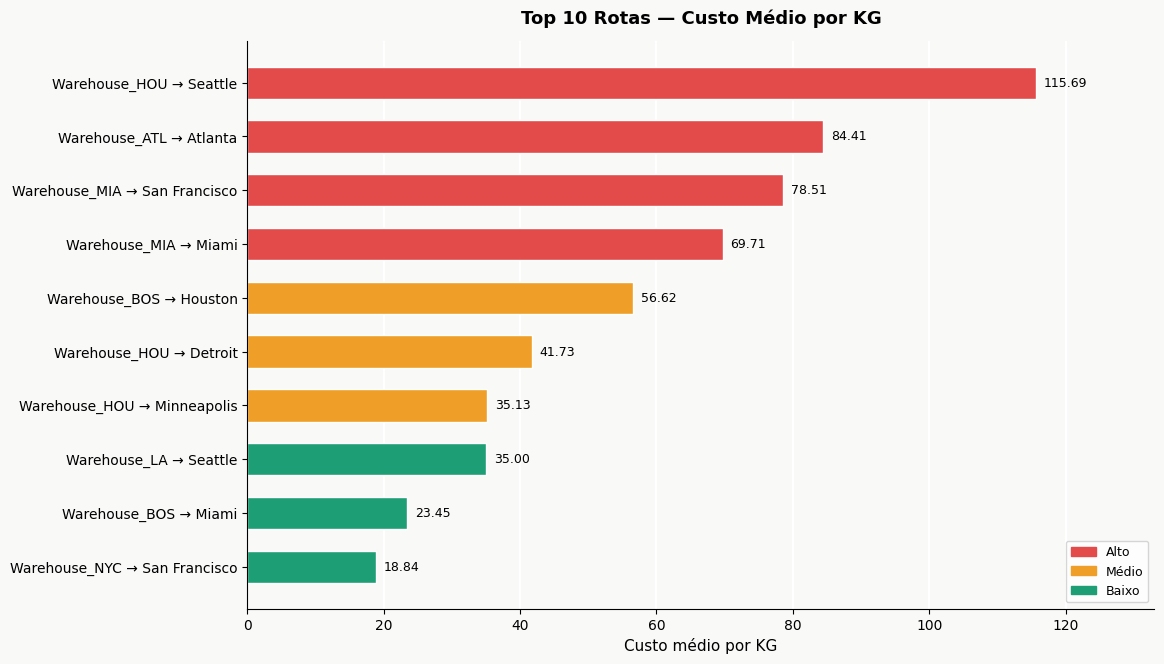

In [111]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#f9f9f8')

custo_plot = custo_por_kg.nlargest(10, 'media_custo_por_kg').copy()
custo_plot['rota'] = custo_plot['armazem_origem'] + ' → ' + custo_plot['destino']
custo_plot = custo_plot.sort_values('media_custo_por_kg', ascending=True)

rotas  = custo_plot['rota'].tolist()
custos = custo_plot['media_custo_por_kg'].tolist()

def cor(i, total):
    t = i / (total - 1)
    if t >= 0.66: return '#E24B4A'
    if t >= 0.33: return '#EF9F27'
    return '#1D9E75'

cores = [cor(i, len(custos)) for i in range(len(custos))]

bars = ax.barh(rotas, custos, color=cores, edgecolor='white', height=0.6)
ax.set_xlabel('Custo médio por KG', fontsize=11)
ax.set_title('Top 10 Rotas — Custo Médio por KG', fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor('#f9f9f8')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, custos):
    ax.text(val + max(custos) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlim(0, max(custos) * 1.15)

p_verm = mpatches.Patch(color='#E24B4A', label='Alto')
p_lara = mpatches.Patch(color='#EF9F27', label='Médio')
p_verd = mpatches.Patch(color='#1D9E75', label='Baixo')
ax.legend(handles=[p_verm, p_lara, p_verd], fontsize=9, loc='lower right')

plt.tight_layout(pad=2)
plt.savefig('custo_por_kg_rotas.png', dpi=150, bbox_inches='tight')
plt.show()

# análise de evolução das entregas ao longo do tempo — envios

agrupamento por mês de envio para identificar padrões temporais
de volume e taxa de atraso ao longo de 2023.

**padrões identificados:**
- junho apresenta a menor taxa de atraso do ano (15.34%)
- outubro concentra a maior taxa de atraso (25.15%) com 43 atrasos
- março e agosto também apresentam picos com 24.55% e 25.00% respectivamente
- agosto tem o maior volume de envios (180)

**insight:** os meses de março, agosto e outubro concentram os maiores índices de atraso, sugerindo sazonalidade trimestral com sobrecarga operacional nesses períodos.

In [112]:
# por data de envio
evolucao_por_envio = (
    df.groupby(df['data_envio'].dt.to_period('M'))
    .agg(
        total_envios=('id_envio', 'count'),
        total_atrasados=('entregas_atrasadas', 'sum')
    )
    .assign(taxa_atraso=lambda x: x['total_atrasados'] / x['total_envios'] * 100)
)

print(evolucao_por_envio)

            total_envios total_atrasados taxa_atraso
data_envio                                          
2023-01              163              28   17.177914
2023-02              135              24   17.777778
2023-03              167              41   24.550898
2023-04              161              35    21.73913
2023-05              172              33   19.186047
2023-06              163              25   15.337423
2023-07              165              30   18.181818
2023-08              180              45        25.0
2023-09              161              29   18.012422
2023-10              171              43   25.146199
2023-11              177              36   20.338983
2023-12              168              38   22.619048


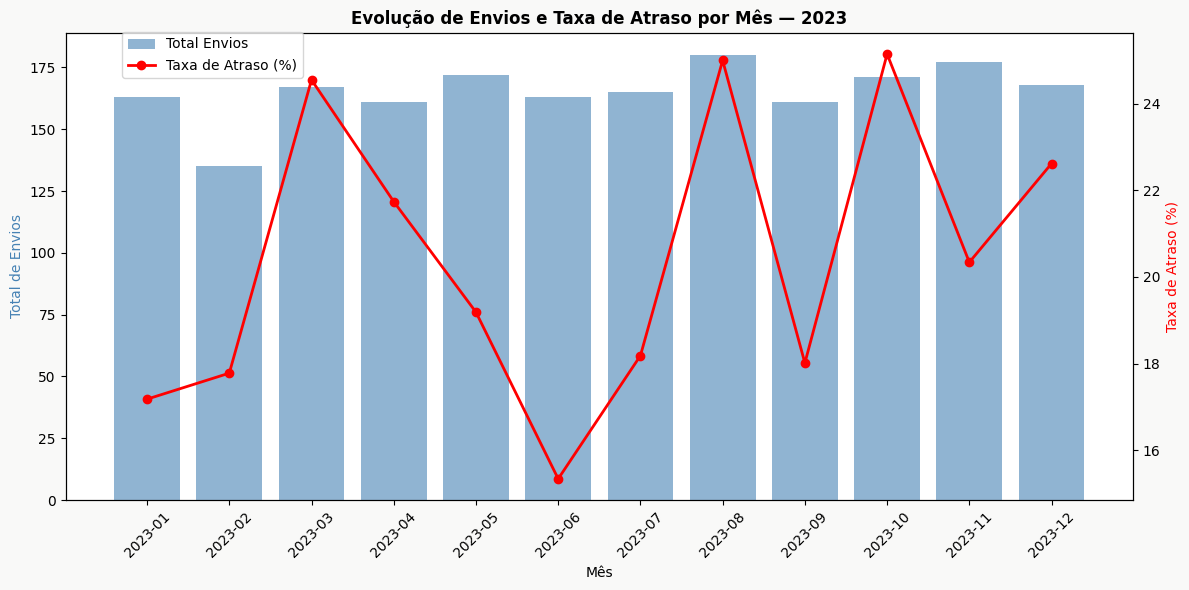

In [113]:
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

# Eixo esquerdo - total de envios
ax1.bar(evolucao_por_envio.index.astype(str),
        evolucao_por_envio['total_envios'],
        color='steelblue', alpha=0.6, label='Total Envios')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Total de Envios', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Eixo direito - taxa de atraso
ax2 = ax1.twinx()
ax2.plot(evolucao_por_envio.index.astype(str),
         evolucao_por_envio['taxa_atraso'],
         color='red', marker='o', linewidth=2, label='Taxa de Atraso (%)')
ax2.set_ylabel('Taxa de Atraso (%)', color='red')

# Titulo e legenda
plt.title('Evolução de Envios e Taxa de Atraso por Mês — 2023', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))

plt.tight_layout()
plt.savefig('evolucao_envios_taxa.png', dpi=150, bbox_inches='tight')
plt.show()

# análise de evolução das entregas ao longo do tempo — entregas

agrupamento por mês de entrega para identificar padrões temporais
de volume e taxa de atraso ao longo de 2023.

**padrões identificados:**
- volume de entregas estável ao longo do ano (entre 128 e 178 por mês)
- junho/2023 apresenta a menor taxa de atraso (14.74%)
- abril/2023 concentra a maior taxa do ano (23.68%)
- janeiro/2024 registra pico crítico de 34.21% com apenas 38 entregas — evidência de entregas de dezembro que atrasaram e chegaram no mês seguinte

**insight:** o pico de atrasos em janeiro/2024 não representa aumento de volume, mas sim o impacto das entregas atrasadas de dezembro.

isso sugere que o período de festas sobrecarrega a operação e gera efeito cascata no mês seguinte.

In [114]:
# por data de entrega
evolucao_por_entrega = (
    df.groupby(df['data_entrega'].dt.to_period('M'))
    .agg(
        total_entregas=('id_envio', 'count'),
        total_atrasados=('entregas_atrasadas', 'sum')
    )
    .assign(taxa_atraso=lambda x: x['total_atrasados'] / x['total_entregas'] * 100)
)

print(evolucao_por_entrega)

              total_entregas total_atrasados taxa_atraso
data_entrega                                            
2023-01                  136              22   16.176471
2023-02                  128              23    17.96875
2023-03                  168              36   21.428571
2023-04                  152              36   23.684211
2023-05                  170              38   22.352941
2023-06                  156              23    14.74359
2023-07                  167              30   17.964072
2023-08                  178              41   23.033708
2023-09                  169              36   21.301775
2023-10                  163              37   22.699387
2023-11                  166              38   22.891566
2023-12                  161              34   21.118012
2024-01                   38              13   34.210526


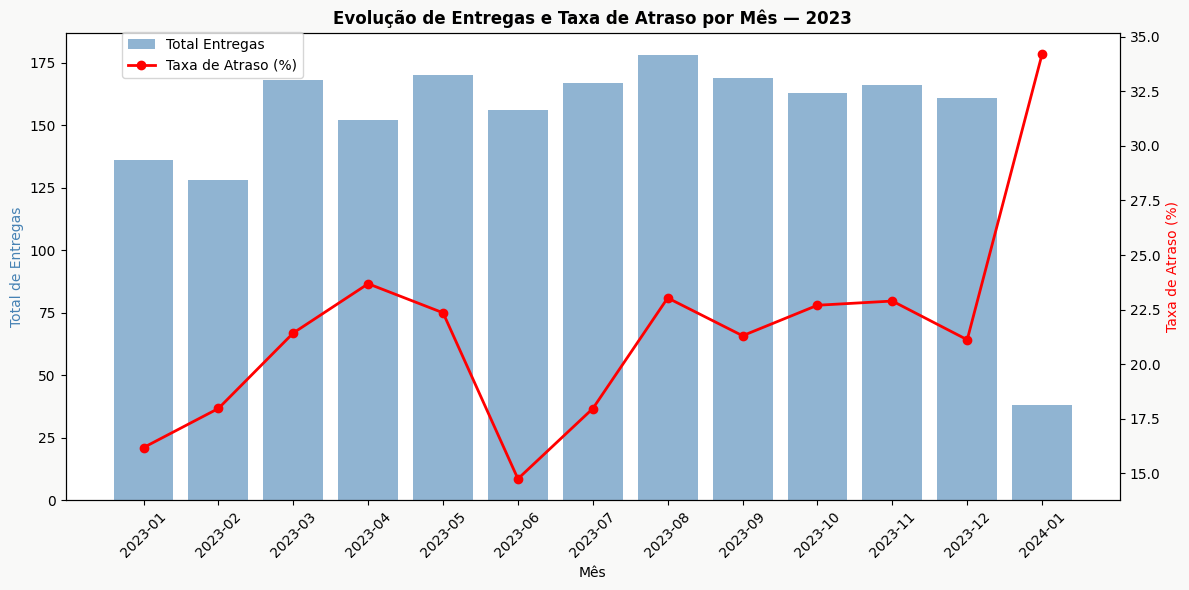

In [115]:
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

# Eixo esquerdo - total de entregas
ax1.bar(evolucao_por_entrega.index.astype(str),
        evolucao_por_entrega['total_entregas'],
        color='steelblue', alpha=0.6, label='Total Entregas')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Total de Entregas', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Eixo direito - taxa de atraso
ax2 = ax1.twinx()
ax2.plot(evolucao_por_entrega.index.astype(str),
         evolucao_por_entrega['taxa_atraso'],
         color='red', marker='o', linewidth=2, label='Taxa de Atraso (%)')
ax2.set_ylabel('Taxa de Atraso (%)', color='red')

# Titulo e legenda
plt.title('Evolução de Entregas e Taxa de Atraso por Mês — 2023', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))

plt.tight_layout()
plt.savefig('evolucao_entregas_taxa.png', dpi=150, bbox_inches='tight')
plt.show()

# evolução de envios e entregas — taxa de atraso por mês

comparação entre a taxa de atraso por data de envio e por data de entrega ao longo de 2023.

**métricas:**
- barras azuis → volume total de envios por mês
- barras verdes → volume total de entregas por mês
- linha vermelha → taxa de atraso por data de envio
- linha laranja → taxa de atraso por data de entrega

**insights identificados:**
- os volumes de envio e entrega são estáveis ao longo do ano (entre 128 e 180 por mês)
- há uma relação de efeito cascata entre as duas taxas — picos de atraso no envio tendem a gerar picos de atraso na entrega no mês seguinte
- pico de envios atrasados em outubro → impacto nas entregas de novembro
- pico de dezembro → causa o pico crítico de janeiro/2024 (34.21%) na taxa de entrega
- junho apresenta a menor taxa de atraso em ambas as métricas — melhor mês operacional do ano

**conclusão:** os atrasos no despacho geram efeito cascata nas entregas do mês seguinte,
sugerindo que a sobrecarga operacional em determinados períodos impacta diretamente
a experiência do cliente no mês subsequente.

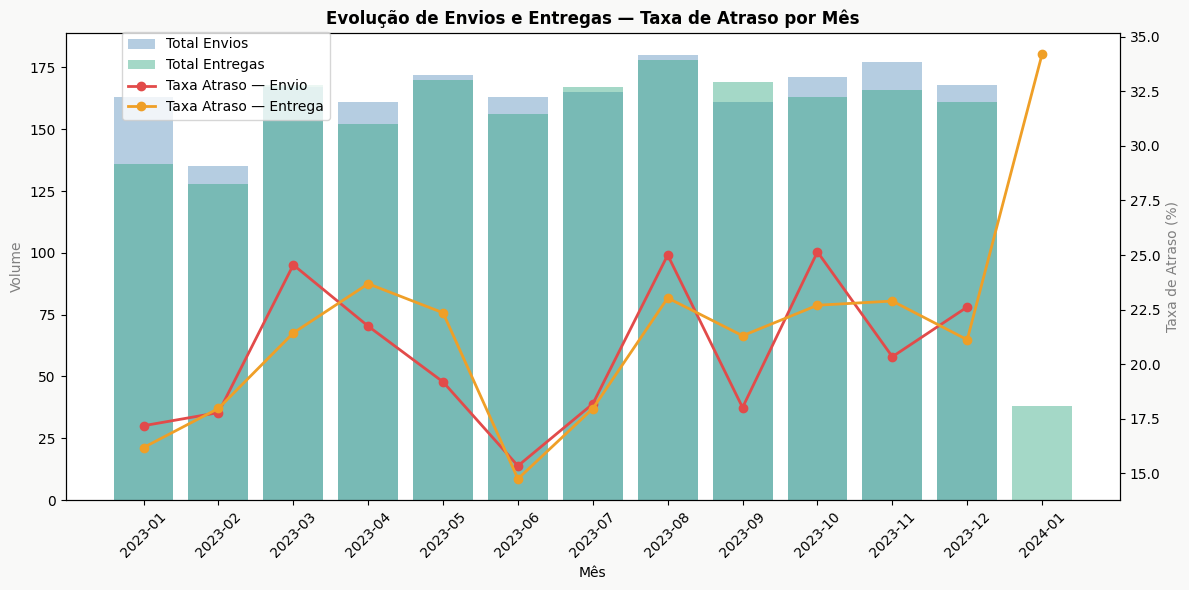

In [116]:
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f9f9f8')

# eixo esquerdo — volume
ax1.bar(evolucao_por_envio.index.astype(str),
        evolucao_por_envio['total_envios'],
        color='steelblue', alpha=0.4, label='Total Envios')
ax1.bar(evolucao_por_entrega.index.astype(str),
        evolucao_por_entrega['total_entregas'],
        color='#1D9E75', alpha=0.4, label='Total Entregas')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Volume', color='gray')
ax1.tick_params(axis='x', rotation=45)

# eixo direito — taxa de atraso
ax2 = ax1.twinx()
ax2.plot(evolucao_por_envio.index.astype(str),
         evolucao_por_envio['taxa_atraso'],
         color='#E24B4A', marker='o', linewidth=2, label='Taxa Atraso — Envio')
ax2.plot(evolucao_por_entrega.index.astype(str),
         evolucao_por_entrega['taxa_atraso'],
         color='#EF9F27', marker='o', linewidth=2, label='Taxa Atraso — Entrega')
ax2.set_ylabel('Taxa de Atraso (%)', color='gray')

plt.title('Evolução de Envios e Entregas — Taxa de Atraso por Mês', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))

plt.tight_layout()
plt.savefig('evolucao_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════
# PARTE 5 — GRÁFICOS EXPLORATÓRIOS
# ══════════════════════════════════

# top 10 cidades que mais recebem entregas

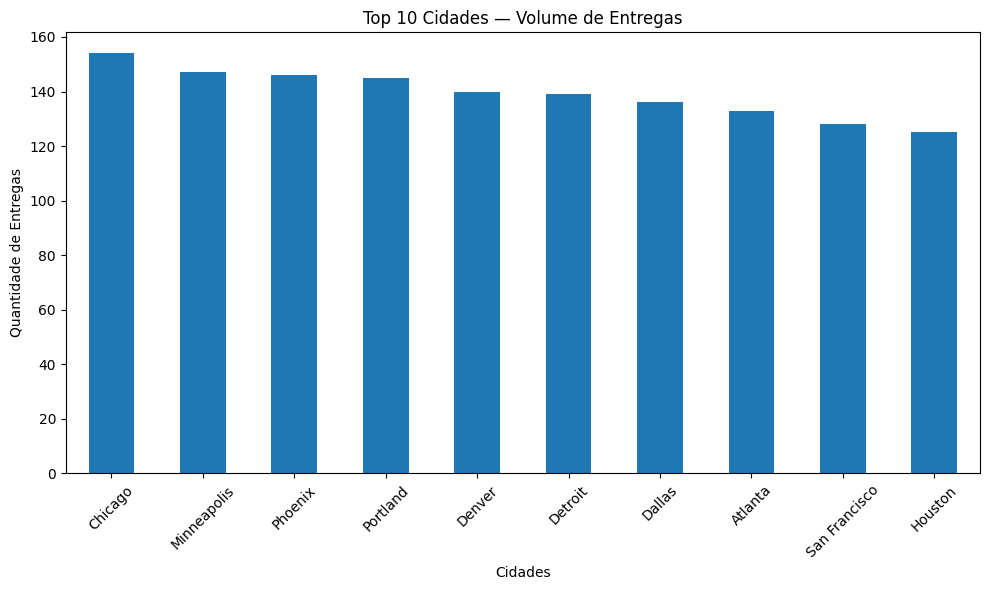

In [117]:
# top 10 cidades que mais recebem entregas
Destination_city = df['destino'].value_counts().head(10)

plt.figure(figsize=(10, 6))
Destination_city.plot(kind='bar')
plt.title('Top 10 Cidades — Volume de Entregas')
plt.xlabel('Cidades')
plt.ylabel('Quantidade de Entregas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# volume de entrega das transportadoras

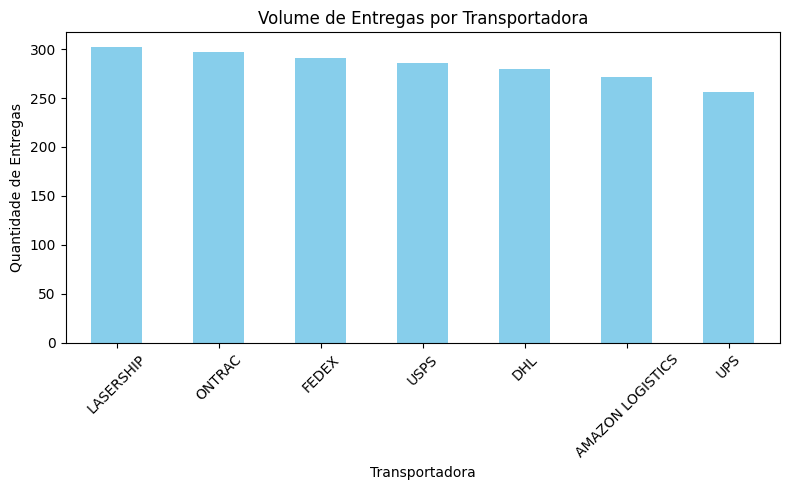

In [118]:
delivery_carrier = df['transportadora'].value_counts()

plt.figure(figsize=(8, 5))
delivery_carrier.plot(kind='bar', color='skyblue')
plt.title('Volume de Entregas por Transportadora')
plt.xlabel('Transportadora')
plt.ylabel('Quantidade de Entregas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# volume de saídas dos depósitos de origem

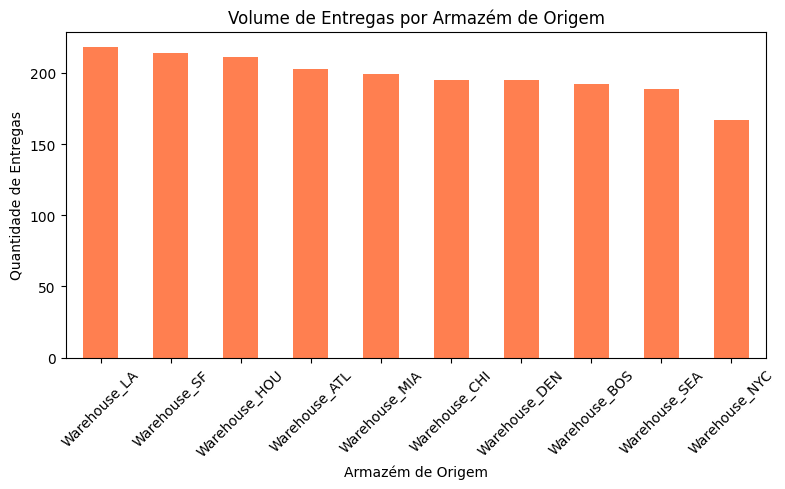

In [119]:
deliveries_warehouse = df['armazem_origem'].value_counts()

plt.figure(figsize=(8, 5))
deliveries_warehouse.plot(kind='bar', color='coral')
plt.title('Volume de Entregas por Armazém de Origem')
plt.xlabel('Armazém de Origem')
plt.ylabel('Quantidade de Entregas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# mapa de volume de envios por cidade/estado

In [120]:
coords = {
    'San Francisco': (37.7749, -122.4194),
    'Los Angeles':   (34.0522, -118.2437),
    'New York':      (40.7128,  -74.0060),
    'Boston':        (42.3601,  -71.0589),
    'Chicago':       (41.8781,  -87.6298),
    'Houston':       (29.7604,  -95.3698),
    'Detroit':       (42.3314,  -83.0458),
    'Atlanta':       (33.7490,  -84.3880),
    'Miami':         (25.7617,  -80.1918),
    'Dallas':        (32.7767,  -96.7970),
    'Seattle':       (47.6062, -122.3321),
    'Denver':        (39.7392, -104.9903),
    'Phoenix':       (33.4484, -112.0740),
    'Portland':      (45.5051, -122.6750),
    'Minneapolis':   (44.9778,  -93.2650),
}

plot = (
    df.groupby('destino')['id_envio'].count()
    .reset_index(name='total_envios')
    .assign(
        lat=lambda x: x['destino'].map(lambda c: coords.get(c, (None, None))[0]),
        lon=lambda x: x['destino'].map(lambda c: coords.get(c, (None, None))[1]),
    )
    .dropna(subset=['lat', 'lon'])
)

fig = go.Figure()
fig.add_trace(go.Scattergeo(
    lon=plot['lon'],
    lat=plot['lat'],
    text=plot.apply(lambda r: f"{r['destino']}<br>{r['total_envios']:,} envios", axis=1),
    mode='markers',
    marker=dict(
        size=plot['total_envios'] / plot['total_envios'].max() * 50 + 8,
        color=plot['total_envios'],
        colorscale=[[0, '#7B0000'], [0.5, '#C0392B'], [1, '#FF1A1A']],
        showscale=True,
        colorbar=dict(title='Envios'),
        line=dict(color='white', width=0.8),
        opacity=0.85,
    ),
    hovertemplate='%{text}<extra></extra>',
))

fig.update_layout(
    title=dict(text='Volume de Envios por Cidade Destino — EUA', font=dict(size=16)),
    geo=dict(
        scope='usa',
        showland=True,
        landcolor='#f0f0ee',
        showlakes=True,
        lakecolor='#d0e4f7',
        showcoastlines=True,
        coastlinecolor='#aaaaaa',
        projection_type='albers usa',
    ),
    paper_bgcolor='#f9f9f8',
    margin=dict(l=0, r=0, t=40, b=0),
    height=550,
)

fig.show()

In [121]:
df['destino'].value_counts()

,count
destino,
Chicago,154
Minneapolis,147
Phoenix,146
Portland,145
Denver,140
Detroit,139
Dallas,136
Atlanta,133
San Francisco,128


# mapa de volume de envios por armazem

In [122]:
coords_armazem = {
    'Warehouse_MIA': (25.7617,  -80.1918),
    'Warehouse_LA':  (34.0522, -118.2437),
    'Warehouse_BOS': (42.3601,  -71.0589),
    'Warehouse_SF':  (37.7749, -122.4194),
    'Warehouse_ATL': (33.7490,  -84.3880),
    'Warehouse_CHI': (41.8781,  -87.6298),
    'Warehouse_HOU': (29.7604,  -95.3698),
    'Warehouse_SEA': (47.6062, -122.3321),
    'Warehouse_NYC': (40.7128,  -74.0060),
    'Warehouse_DEN': (39.7392, -104.9903),
}

plot = (
    df.groupby('armazem_origem')['id_envio'].count()
    .reset_index(name='total_envios')
    .assign(
        lat=lambda x: x['armazem_origem'].map(lambda c: coords_armazem.get(c, (None, None))[0]),
        lon=lambda x: x['armazem_origem'].map(lambda c: coords_armazem.get(c, (None, None))[1]),
    )
    .dropna(subset=['lat', 'lon'])
)

fig = go.Figure()
fig.add_trace(go.Scattergeo(
    lon=plot['lon'],
    lat=plot['lat'],
    text=plot.apply(lambda r: f"{r['armazem_origem']}<br>{r['total_envios']:,} envios", axis=1),
    mode='markers',
    marker=dict(
        size=plot['total_envios'] / plot['total_envios'].max() * 50 + 8,
        color=plot['total_envios'],
        colorscale=[[0, '#7B0000'], [0.5, '#C0392B'], [1, '#FF1A1A']],
        showscale=True,
        colorbar=dict(title='Envios'),
        line=dict(color='white', width=0.8),
        opacity=0.85,
    ),
    hovertemplate='%{text}<extra></extra>',
))

fig.update_layout(
    title=dict(text='Volume de Envios por Armazém — EUA', font=dict(size=16)),
    geo=dict(
        scope='usa',
        showland=True,
        landcolor='#f0f0ee',
        showlakes=True,
        lakecolor='#d0e4f7',
        showcoastlines=True,
        coastlinecolor='#aaaaaa',
        projection_type='albers usa',
    ),
    paper_bgcolor='#f9f9f8',
    margin=dict(l=0, r=0, t=40, b=0),
    height=550,
)

fig.show()

In [123]:
df['armazem_origem'].value_counts()

,count
armazem_origem,
Warehouse_LA,218
Warehouse_SF,214
Warehouse_HOU,211
Warehouse_ATL,203
Warehouse_MIA,199
Warehouse_CHI,195
Warehouse_DEN,195
Warehouse_BOS,192
Warehouse_SEA,189


# ══════════════════════════════════ #